<a href="https://colab.research.google.com/github/Miguithub/Wavelets/blob/vpn_btc/Wavelets_VNP_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LIBRERIAS 1

In [ ]:
!pip install statsmodels

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


---

# DE

In [ ]:
btc = pd.read_parquet('/content/drive/MyDrive/mf12024.parquet')

In [ ]:
# eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
# sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   open_time               int64  
 1   open                    float64
 2   high                    float64
 3   low                     float64
 4   close                   float64
 5   volume                  float64
 6   close_time              int64  
 7   quote_volume            float64
 8   trade_count             int64  
 9   taker_buy_base_volume   float64
 10  taker_buy_quote_volume  float64
 11  ignore                  int64  
dtypes: float64(8), int64(4)
memory usage: 2.8 GB


In [ ]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
31622395,1735689595000,93576.00,93576.01,93576.00,93576.01,0.00083,1735689595999,77.668087,2,0.00067,62.695927,0
31622396,1735689596000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689596999,0.000000,0,0.00000,0.000000,0
31622397,1735689597000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689597999,0.000000,0,0.00000,0.000000,0
31622398,1735689598000,93576.01,93576.01,93576.01,93576.01,0.00094,1735689598999,87.961449,3,0.00094,87.961449,0
31622399,1735689599000,93576.00,93576.00,93576.00,93576.00,0.00217,1735689599999,203.059920,3,0.00000,0.000000,0


In [ ]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1704067200000,42283.58,42283.59,42283.58,42283.58,0.07625,1704067200999,3224.123141,21,0.01658,701.061922,0
1,1704067201000,42283.59,42283.59,42283.58,42283.58,1.37528,1704067201999,58151.769471,51,0.75683,32001.489420,0
2,1704067202000,42283.58,42283.59,42283.58,42283.58,0.18867,1704067202999,7977.643051,9,0.00124,52.431652,0
3,1704067203000,42283.58,42283.59,42283.58,42283.59,0.83488,1704067203999,35301.720464,39,0.51935,21959.982467,0
4,1704067204000,42283.58,42283.59,42283.58,42283.59,0.23809,1704067204999,10067.297927,17,0.03653,1544.619543,0


Cleaness

In [ ]:
import pandas as pd

# Usá el nombre real de tu columna temporal
t = pd.to_datetime(btc["close_time"])

# diferencias entre timestamps en segundos
d = t.diff().dt.total_seconds()

# chequeo de equidistancia
es_equidistante = d.iloc[1:].nunique() == 1

print("Equidistante:", es_equidistante)
print("Intervalo único (segundos):", d.iloc[1] if es_equidistante else "No uniforme")

Equidistante: True
Intervalo único (segundos): 1e-06


In [ ]:
del t, d
import gc
gc.collect()

149

In [ ]:
btc.drop(columns=btc.columns[0], inplace=True)
btc["time"] = pd.to_datetime(btc["close_time"] // 1000, unit="s")
cols = ["time"] + [c for c in btc.columns if c not in ["time", "close_time"]]
btc = btc[cols]

In [ ]:
btc["day"] = btc["time"].dt.weekday + 1
btc.loc[btc["day"] == 7, "day"] = 0

In [ ]:
btc.tail()

,time,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore,day
31622395,2024-12-31 23:59:55,93576.00,93576.01,93576.00,93576.01,0.00083,77.668087,2,0.00067,62.695927,0,2
31622396,2024-12-31 23:59:56,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622397,2024-12-31 23:59:57,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622398,2024-12-31 23:59:58,93576.01,93576.01,93576.01,93576.01,0.00094,87.961449,3,0.00094,87.961449,0,2
31622399,2024-12-31 23:59:59,93576.00,93576.00,93576.00,93576.00,0.00217,203.059920,3,0.00000,0.000000,0,2


In [ ]:
cols = ["time", "day"] + [c for c in btc.columns if c not in ["time", "day"]]
btc = btc[cols]

In [ ]:
btc["close_ln"] = np.log(btc["close"])

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   time                    datetime64[ns]
 1   day                     int64         
 2   open                    float64       
 3   high                    float64       
 4   low                     float64       
 5   close                   float64       
 6   volume                  float64       
 7   quote_volume            float64       
 8   trade_count             int64         
 9   taker_buy_base_volume   float64       
 10  taker_buy_quote_volume  float64       
 11  ignore                  int64         
 12  close_ln                float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 3.1 GB


#Wlts VB non parametric

## r_10 *


In [ ]:
df10 = btc.iloc[:, [0, 1, 5, 12]]
df10 = df10.iloc[::10].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


Media: 2.5120653730677365e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.000290376799758221
Skew: -0.6644163965928828
Deciles:
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
d5 : 0.0
d6 : 1.5112582580911745e-07
d7 : 4.940751749771264e-05
d8 : 0.00013040859643567173
d9 : 0.00026780246966211566
Percentiles mas altos:
d95 : 0.00041478295868806436
d96 : 0.0004653834598781969
d97 : 0.0005335308049401632
d98 : 0.0006348627043620058
d99 : 0.00082801840637032
d100 : 0.01430715525476245
Permiles
p970 : 0.0005335308049401632
p971 : 0.000541870576748817
p972 : 0.0005504572842127686
p973 : 0.0005592279938695307
p974 : 0.0005682853087387143
p975 : 0.0005778918045185033
p976 : 0.0005881440891452153
p977 : 0.0005988980718875149
p978 : 0.0006100198064358578
p979 : 0.0006219765619111564
p980 : 0.0006348627043620058
p981 : 0.0006483678177292883
p982 : 0.0006626566118075346
p983 : 0.0006780131169875573
p984 : 0.000694884315670125
p985 : 0

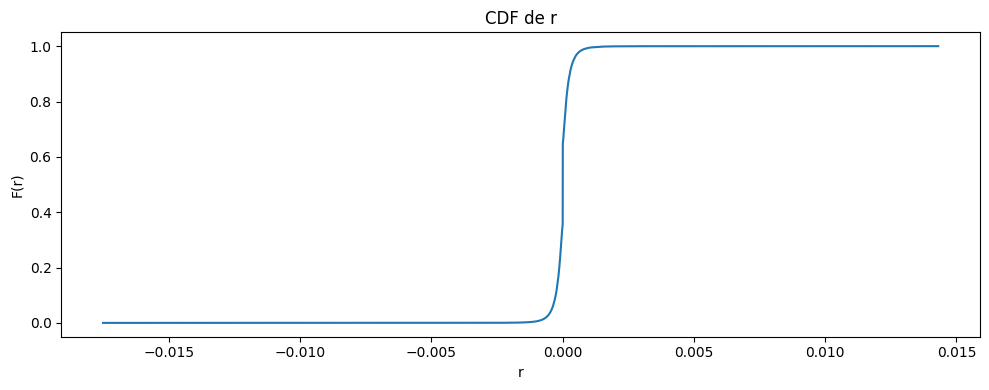

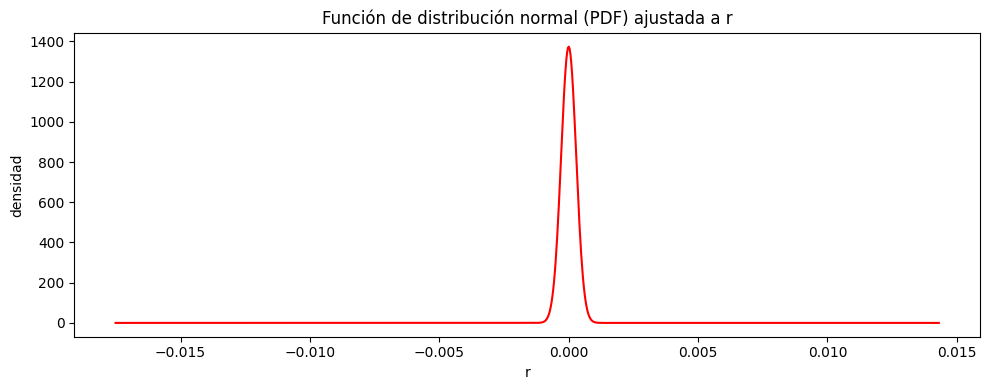

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df10["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.983487          0.016513        0.018851   
1    sym6  6      0.983535          0.016465        0.028615   
2     db6  6      0.983684          0.016316        0.029370   
3    sym4  6      0.983506          0.016494        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        1.349098   788.172962  
1             0.003599        1.346415  1527.291776  
2             0.003750        1.346673  1623.675248  
3             0.003572        1.344478  1625.363930  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00458471 0.00918803 0.01832132 0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.01748336 0.03503767 0.06986659 0.13629791 0.26193334 0.47938114]


###vnp teorica

In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np, pywt

x = df10["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)  # si tenés NaN, swt revienta; mejor imputación simple

J = 6
w = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

coeffs = pywt.swt(xp, w, level=J, trim_approx=False)

# Detalles por nivel
for j in range(1, J + 1):
    df10[f"j{j}"] = coeffs[J - j][1][:n]   # cDj
df10[f"a{J}"] = coeffs[-1][0][:n]          # cAJ

In [ ]:
df10.info()

Bloque elegido:
Inicio: 2024-06-14 06:44:13
Fin   : 2024-06-14 06:49:13


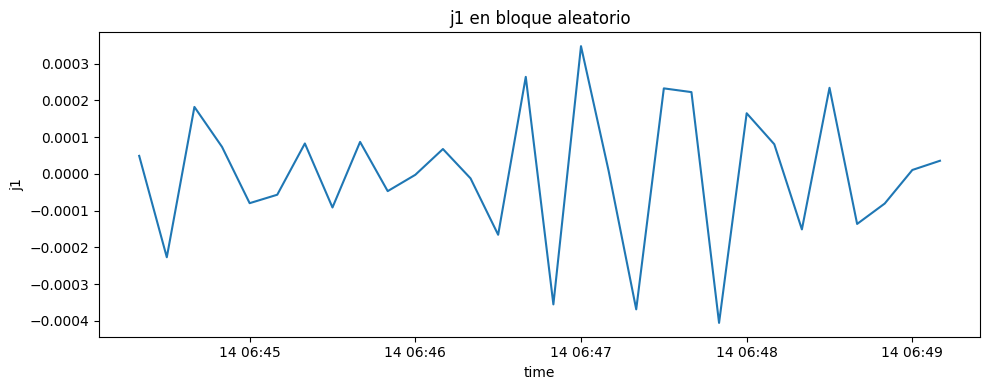

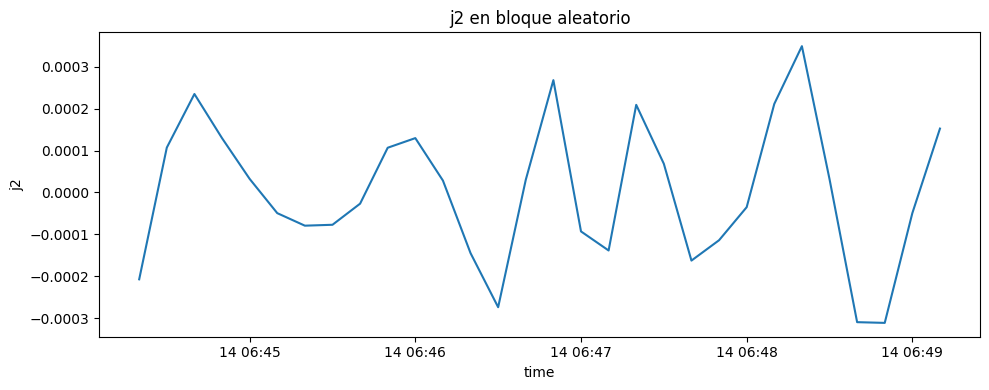

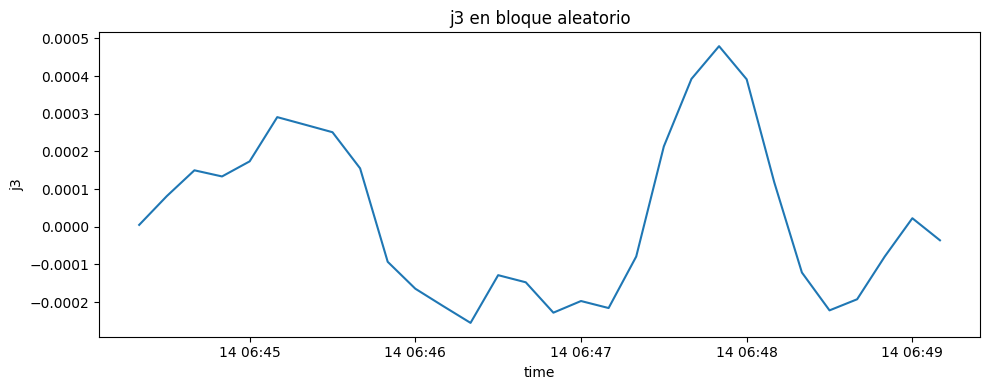

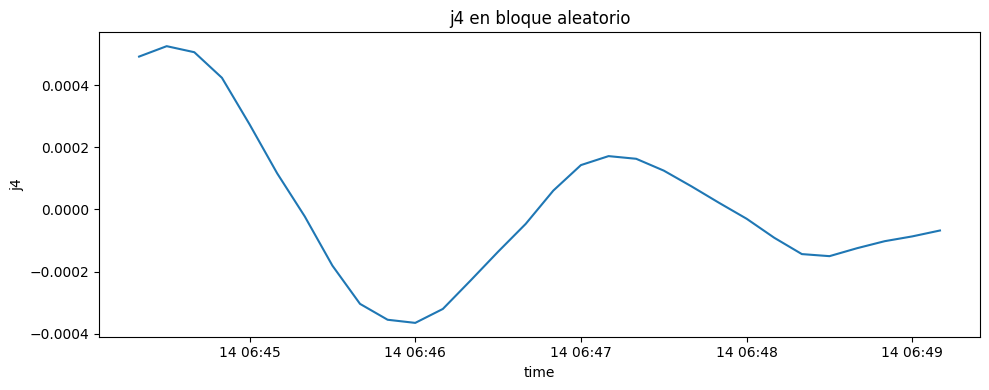

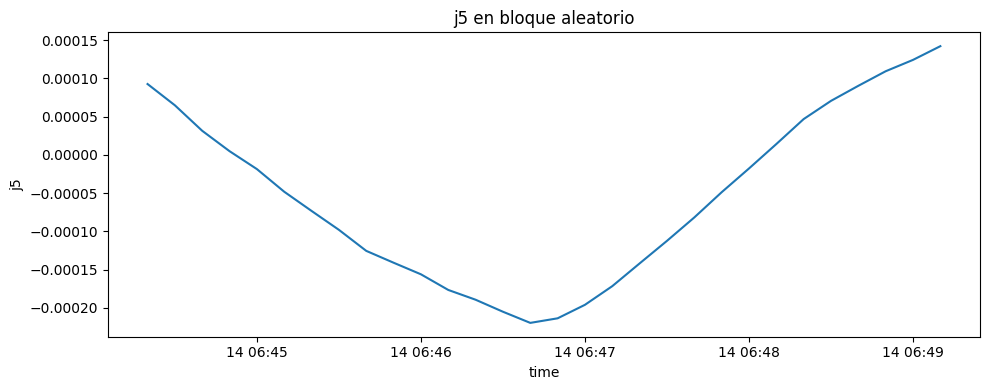

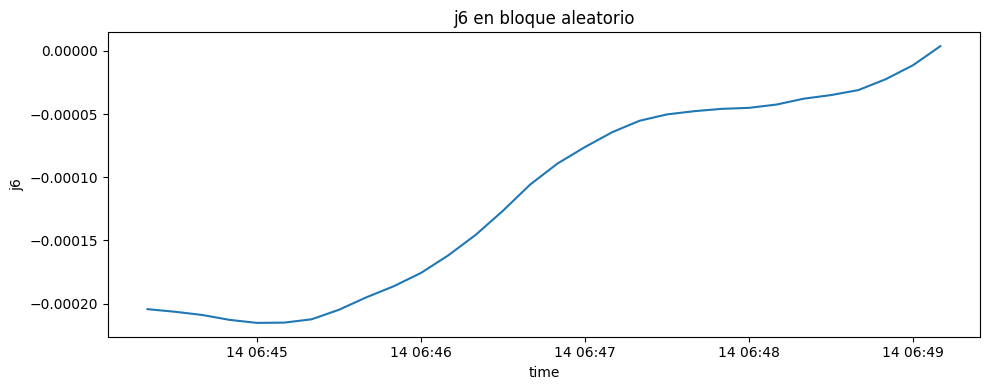

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

In [ ]:
for j in range(1, 7):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

Bloque elegido:
Inicio: 2024-06-14 08:06:46
Fin   : 2024-06-14 08:11:46


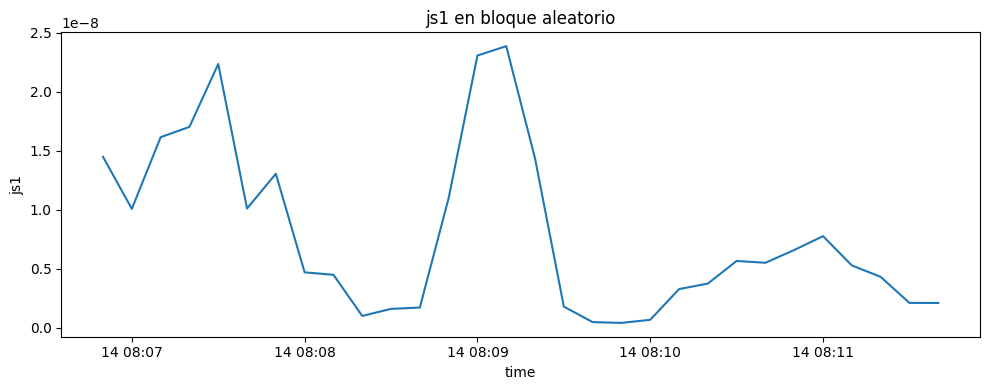

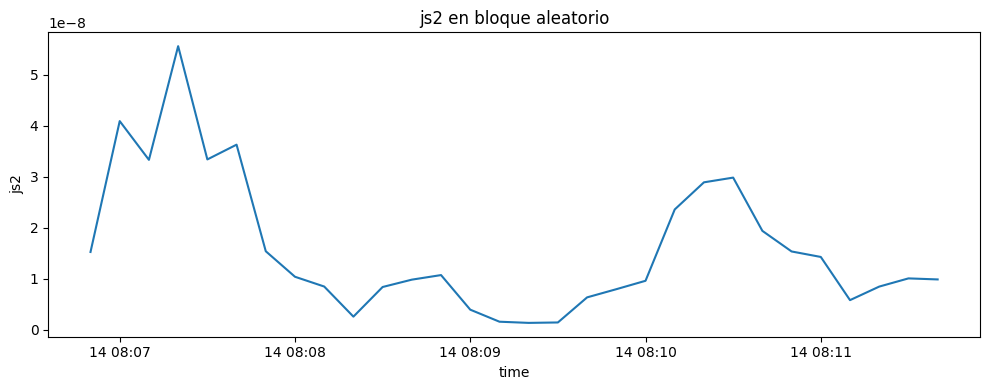

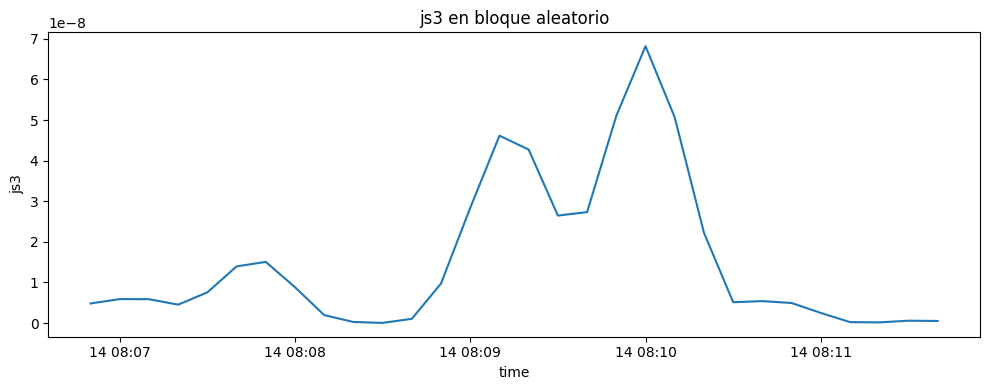

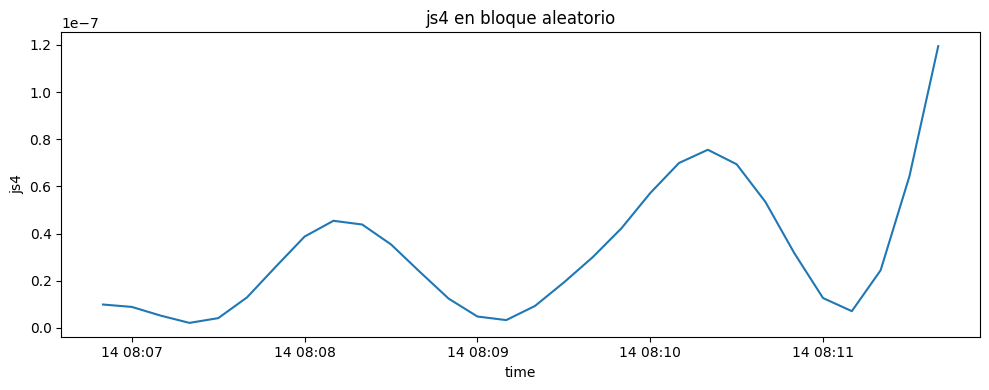

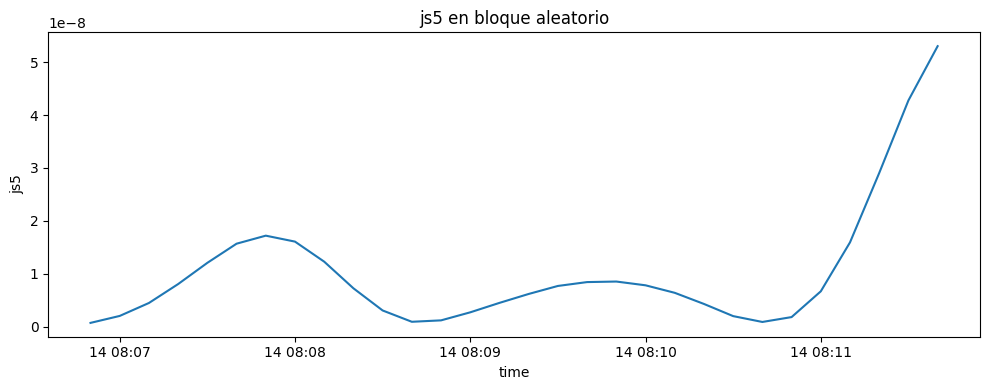

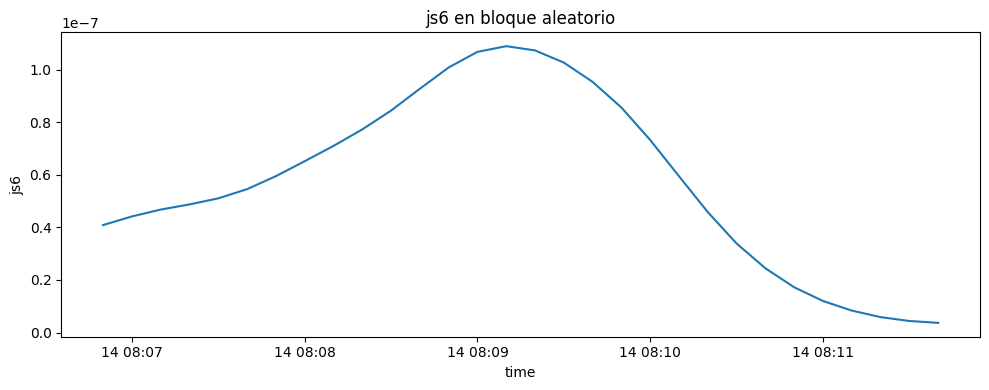

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"] + df10["j2"]
df10["dem"] = df10["j3"] + df10["j4"]
df10["del"] = df10["j5"] + df10["j6"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 0
dem Ceros: 0
dem Nulls: 0
del Ceros: 0
del Nulls: 0


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Eshort, Emedium and ELong all clean***

In [ ]:
df10["es"] = df10["js1"] + df10["js2"]
df10["em"] = df10["js3"] + df10["js4"]
df10["el"] = df10["js5"] + df10["js6"]

In [ ]:
s = df10["es"]
print("es Ceros:", (s == 0).sum())
print("es Nulls:", s.isna().sum())
s = df10["em"]
print("em Ceros:", (s == 0).sum())
print("em Nulls:", s.isna().sum())
s = df10["el"]
print("el Ceros:", (s == 0).sum())
print("el Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

es Ceros: 0
es Nulls: 0
em Ceros: 0
em Nulls: 0
el Ceros: 0
el Nulls: 0


In [ ]:
# dado que no hay ceros va sin epsilon

Bloque elegido:
Inicio: 2024-11-19 02:41:07
Fin   : 2024-11-19 02:46:07


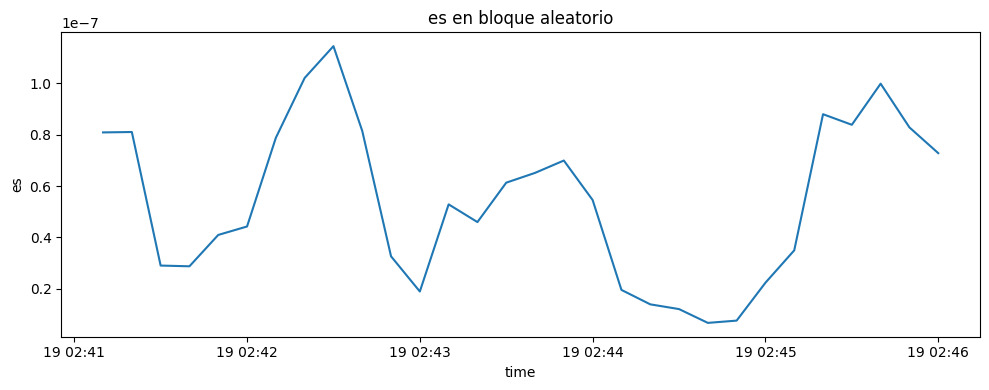

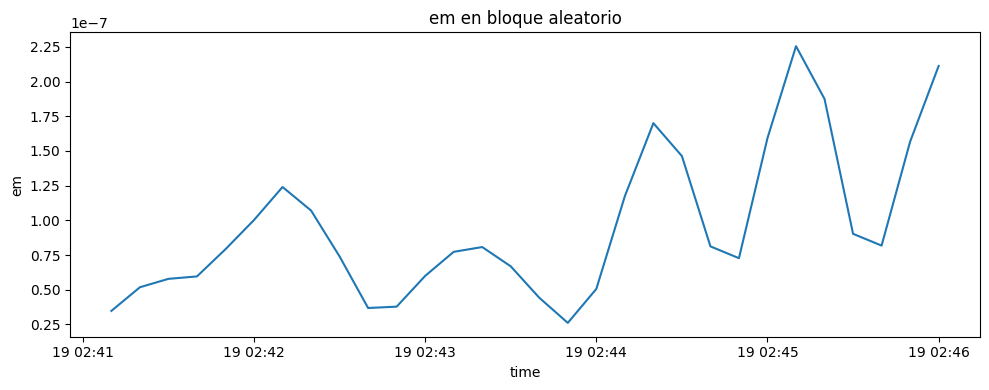

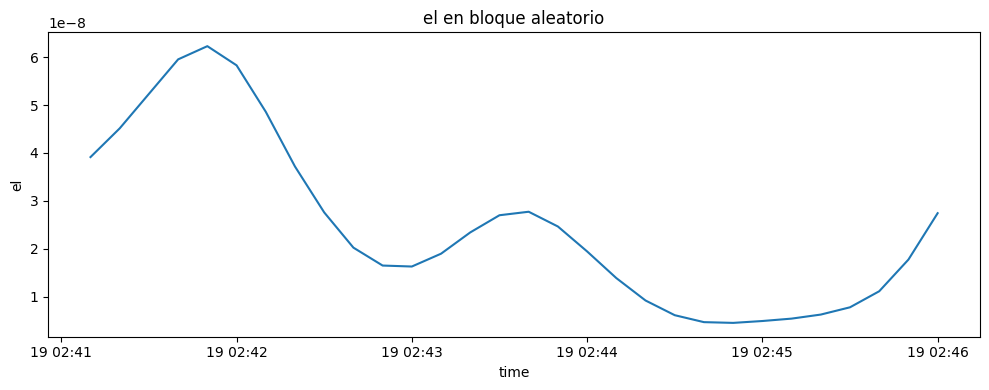

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em y el
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()


***Energia log-relativa***

In [ ]:
df10["e_total"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_total"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 32 columns):
 #   Column        Dtype         
---  ------        -----         
 0   time          datetime64[ns]
 1   day           int64         
 2   close         float64       
 3   close_ln      float64       
 4   r             float64       
 5   RV_r          float64       
 6   j1            float64       
 7   j2            float64       
 8   j3            float64       
 9   j4            float64       
 10  j5            float64       
 11  j6            float64       
 12  a6            float64       
 13  js1           float64       
 14  js2           float64       
 15  js3           float64       
 16  js4           float64       
 17  js5           float64       
 18  js6           float64       
 19  des           float64       
 20  dem           float64       
 21  del           float64       
 22  de_total      float64       
 23  dvol_wlt      float64       
 2

Bloque elegido:
Inicio: 2024-12-20 11:46:10
Fin   : 2024-12-20 12:16:10


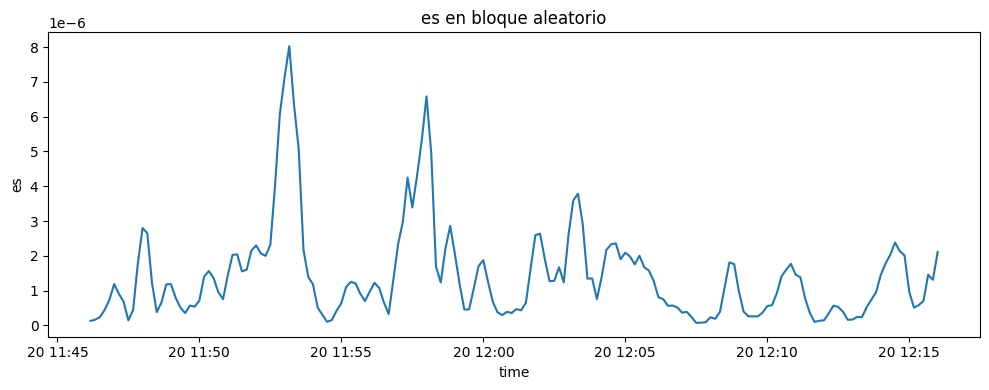

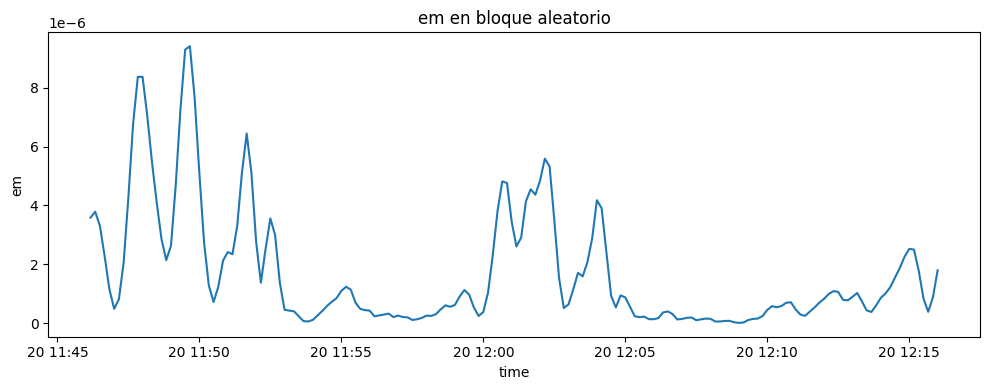

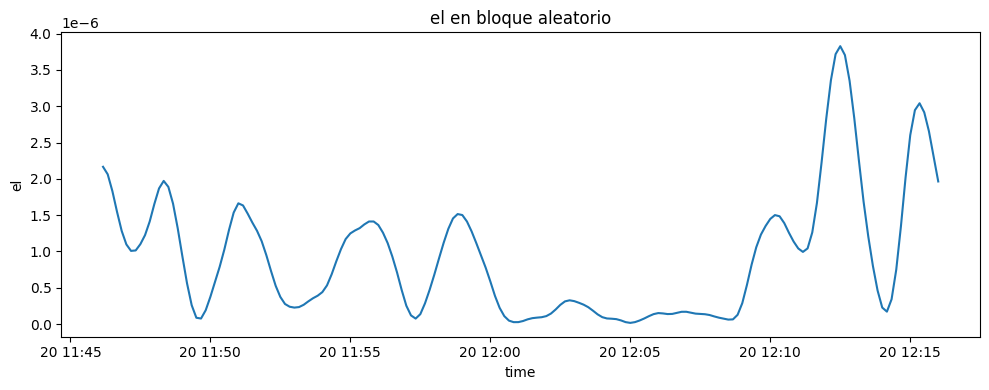

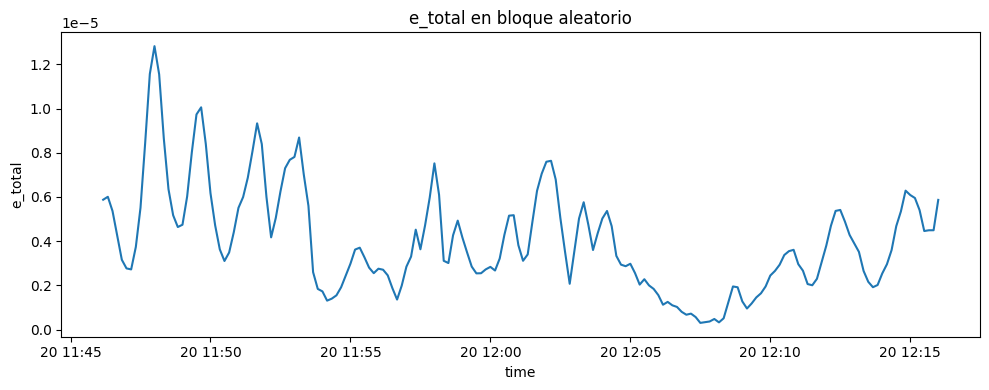

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=30)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el", "e_total"]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em, el y e_total
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()

In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 0


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

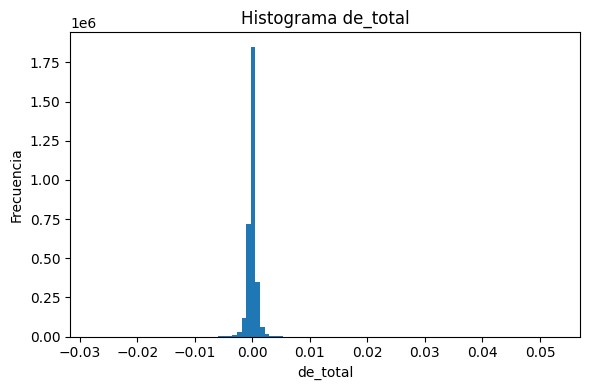

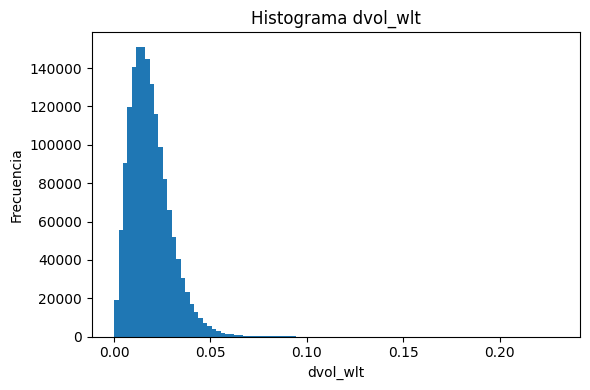

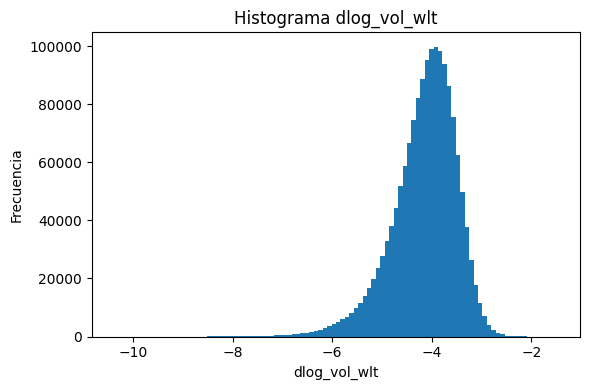

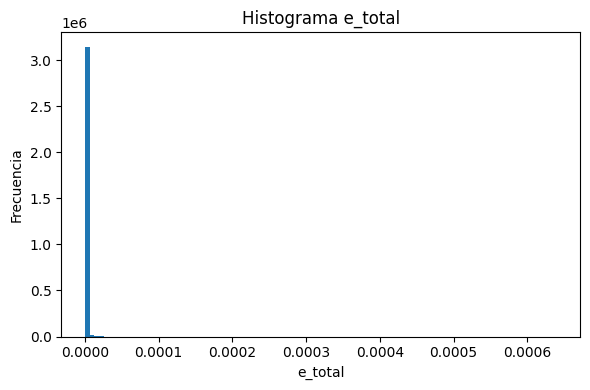

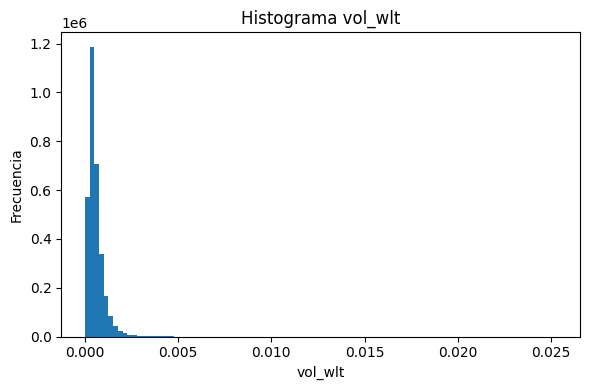

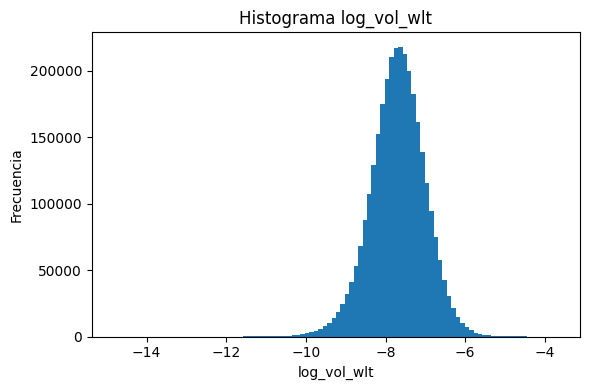

In [ ]:
import matplotlib.pyplot as plt
# Histograma de_total
plt.figure(figsize=(6,4))
plt.hist(df10["de_total"].dropna(), bins=100)
plt.title("Histograma de_total")
plt.xlabel("de_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dvol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dvol_wlt"].dropna(), bins=100)
plt.title("Histograma dvol_wlt")
plt.xlabel("dvol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dlog_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["dlog_vol_wlt"].dropna(), bins=100)
plt.title("Histograma dlog_vol_wlt")
plt.xlabel("dlog_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Individual checks

In [ ]:
import numpy as np
from scipy.stats import skew

s = df15["log_vol_wlt"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)



print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)

Media: -7.6951405930668475
Mediana: -7.6797583615507
Moda: -14.814499408957316
Desvío estándar: 0.6866558271615305
Skew: -0.24768430917128964


In [ ]:
# Moda por bindeo (más representativa)
counts, bins = np.histogram(s, bins=100)
moda_real = bins[np.argmax(counts)]
print("moda bins:", moda_real)

moda bins: -7.686795619731339


Deciles (0.1..0.9): [-8.548225151350989, -8.232745221413321, -8.019208997447066, -7.842356056001769, -7.6797583615507, -7.517218044153186, -7.342826576134334, -7.137836306079423, -6.850075070436032]
Permil 0.005: -9.747002813764164

ACF primeros 20 lags (lag: valor):
 0: 1.000000
 1: 0.985772
 2: 0.957224
 3: 0.926612
 4: 0.902901
 5: 0.884470
 6: 0.867567
 7: 0.853567
 8: 0.842209
 9: 0.834160
10: 0.826791
11: 0.818534
12: 0.809370
13: 0.800697
14: 0.793553
15: 0.788552
16: 0.785715
17: 0.784469
18: 0.783703
19: 0.782373
20: 0.780001


<Figure size 1000x400 with 0 Axes>

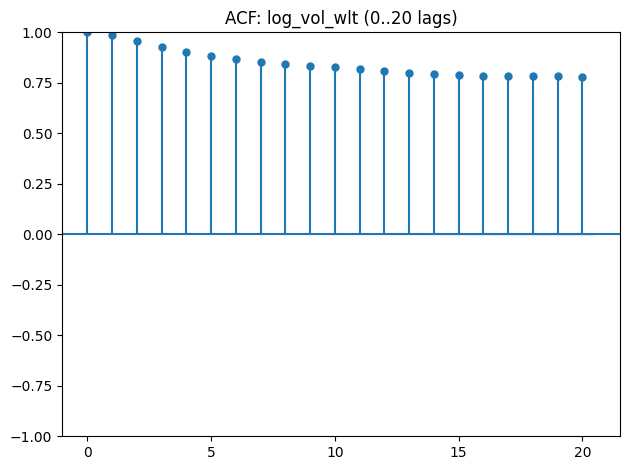


Top 5 días con más obs <= permil 0.005:
day
2024-06-23    1785
2024-06-22    1485
2024-06-09    1289
2024-10-20     923
2024-09-15     581
dtype: int64


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

s = df15["log_vol_wlt"].dropna()

# 1) Deciles + permil 0.005 (0.5%)
deciles = s.quantile(np.arange(0.1, 1.0, 0.1)).tolist()
p0005 = s.quantile(0.005)
print("Deciles (0.1..0.9):", deciles)
print("Permil 0.005:", p0005)

# 2) Autocorrelación: primeros 20 lags + gráfica
acf_vals = acf(s.values, nlags=20, fft=True)  # incluye lag 0
print("\nACF primeros 20 lags (lag: valor):")
for lag, val in enumerate(acf_vals[:21]):
    print(f"{lag:>2}: {val:.6f}")

plt.figure(figsize=(10,4))
plot_acf(s, lags=20, zero=True)
plt.title("ACF: log_vol_wlt (0..20 lags)")
plt.tight_layout()
plt.show()

# 3) Top 5 días con más observaciones <= permil 0.005
d = df15.loc[df15["log_vol_wlt"].le(p0005), ["time"]].dropna()
top5 = (d.assign(day=d["time"].dt.date)
         .groupby("day").size()
         .sort_values(ascending=False)
         .head(5))
print("\nTop 5 días con más obs <= permil 0.005:")
print(top5)

In [ ]:
s = df15["log_vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


Realized variance Test

In [ ]:
# Limpieza mínima
s = df15[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16557027358617013
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
# Limpieza mínima
s = df15[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4228209095367485
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
import statsmodels.api as sm

# Datos
y = df15["RV_r"]
X = df15["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Bloques

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-3283487202.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,8.850302e-07,0.000005,-0.007871,-7.897892,0.000380
1,2024-01-01 00:05:00,8.128024e-07,0.000005,0.004274,-7.843989,0.000398
2,2024-01-01 00:10:00,7.139051e-07,0.000007,-0.006213,-7.664547,0.000473
3,2024-01-01 00:15:00,1.040920e-06,0.000007,0.005542,-7.686534,0.000468
4,2024-01-01 00:20:00,4.248116e-07,0.000006,-0.007190,-7.760870,0.000438


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.37199996020079695
Spearman: 0.9353337535127475
Kendall : 0.7874612700169711


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8774666526779349
Spearman: 0.9189316864022443
Kendall : 0.7635214552776779


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 28 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   day          int64         
 2   close        float64       
 3   close_ln     float64       
 4   r            float64       
 5   RV_r         float64       
 6   j1           float64       
 7   j2           float64       
 8   j3           float64       
 9   j4           float64       
 10  j5           float64       
 11  j6           float64       
 12  a6           float64       
 13  js1          float64       
 14  js2          float64       
 15  js3          float64       
 16  js4          float64       
 17  js5          float64       
 18  js6          float64       
 19  es           float64       
 20  em           float64       
 21  el           float64       
 22  e_total      float64       
 23  ers          float64       
 24  erm          float64   

### VPN productiva j=3 *

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
df10 = btc.iloc[:, [0, 1, 5, 12]]
df10 = df10.iloc[::15].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)

J = 3
w_name = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

# 2. Transformada SWT (Batch)
coeffs = pywt.swt(xp, w_name, level=J, trim_approx=False)

# 3. Cálculo del Desplazamiento (Shift) para db4 en J=6
# Para Daubechies, el soporte del filtro en el nivel J es (2p-1)*(2^J - 1) + 1
p = 4  # Para db4
max_support = (2*p - 1) * (2**J - 1) + 1
shift_size = int(max_support / 2)

# 4. Asignación al DataFrame con alineación causal
for j in range(1, J + 1):
    raw_detail = coeffs[J-j][1][:n]
    df10[f"j{j}"] = pd.Series(raw_detail).shift(shift_size).values
# Aproximación final (a6)
raw_approx = coeffs[-1][0][:n]
df10[f"a{J}"] = pd.Series(raw_approx).shift(shift_size).values

print(f"✅ Features generadas. Shift causal aplicado: {shift_size} filas.")

✅ Features generadas. Shift causal aplicado: 25 filas.


In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 160.8 MB


In [ ]:
for j in range(1, 4):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df10["es"] = df10["js1"]
df10["em"] = df10["js2"]
df10["el"] = df10["js3"]

In [ ]:
df10["e_d"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 25


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_d"])
df10["erm"] = np.log((df10["em"]) / df10["e_d"])
df10["erl"] = np.log((df10["el"]) / df10["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_d"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 25


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

In [ ]:
df10["as3"] = (df10["a3"] * df10["a3"]).rolling(3, min_periods=1).mean()
df10["e_total"] = df10["es"] + df10["em"] + df10["el"] + df10["as3"]

In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["tvol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 25


In [ ]:
df10["tlog_vol_wlt"] = np.log(df10["tvol_wlt"])

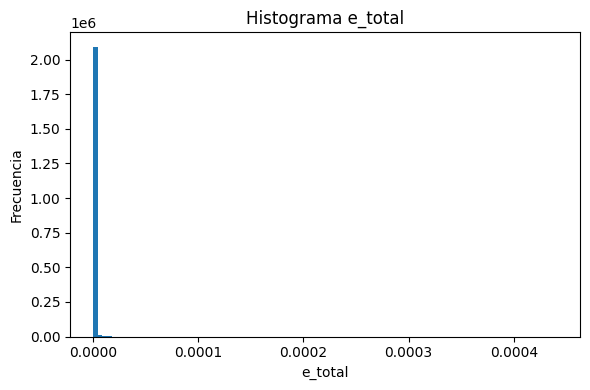

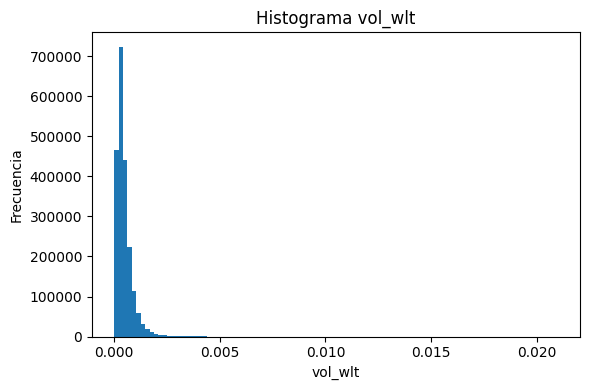

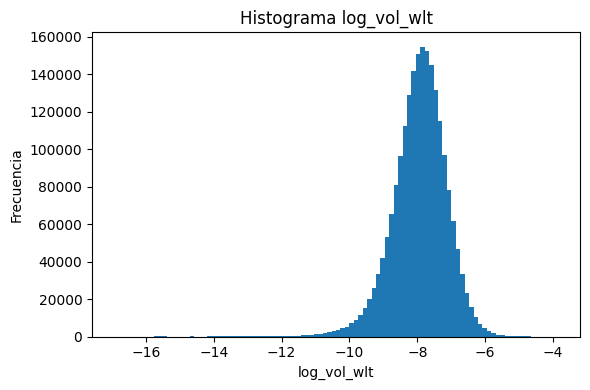

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-08-19 19:56:36
Fin   : 2024-08-19 20:01:36


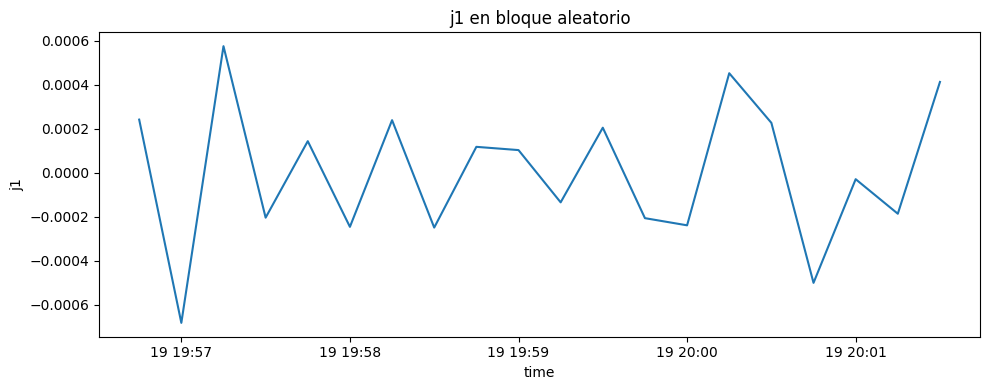

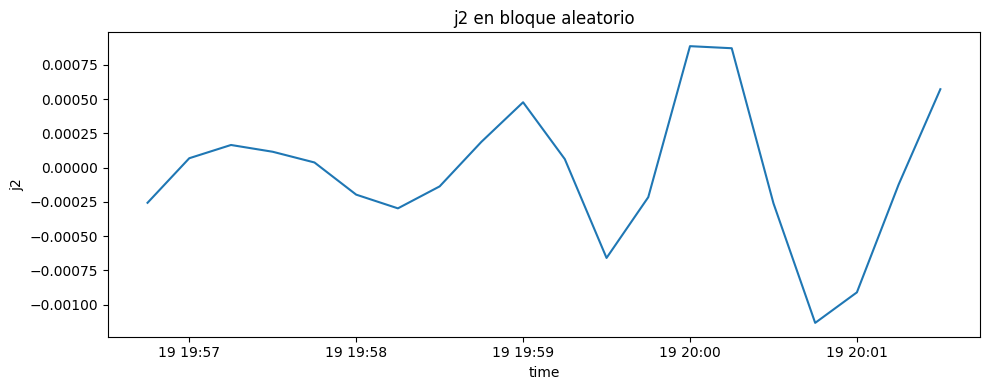

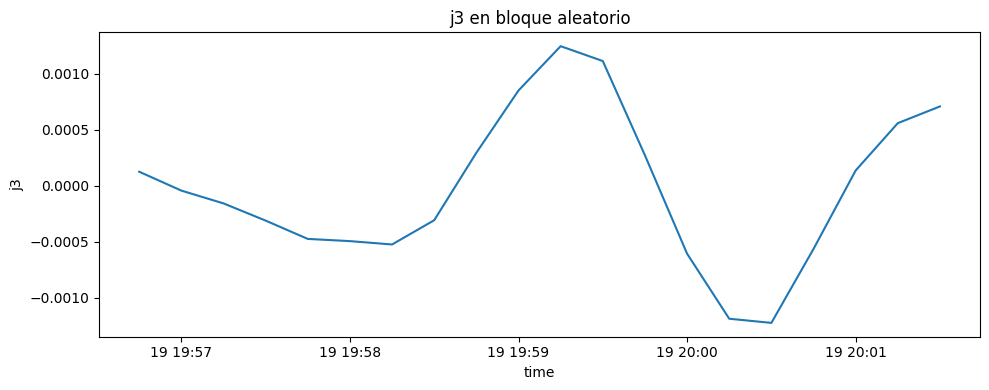

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-05-15 08:22:06
Fin   : 2024-05-15 08:27:06


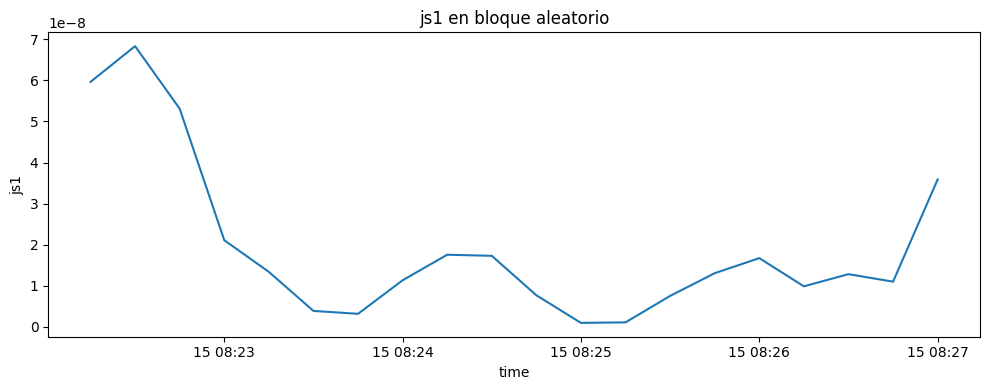

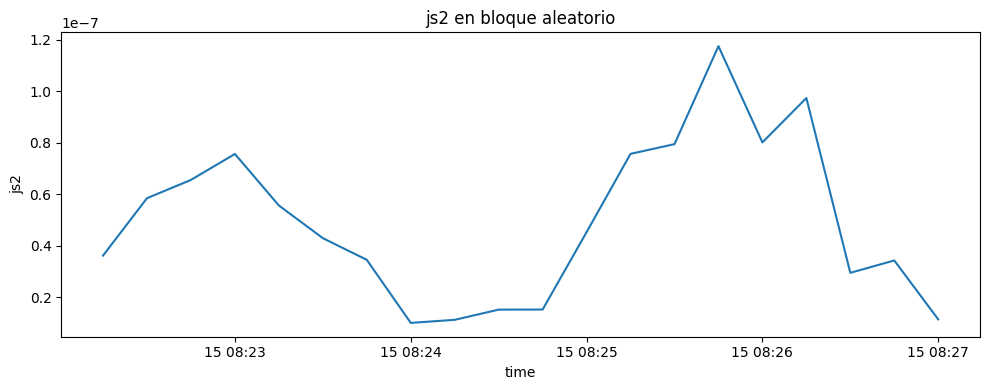

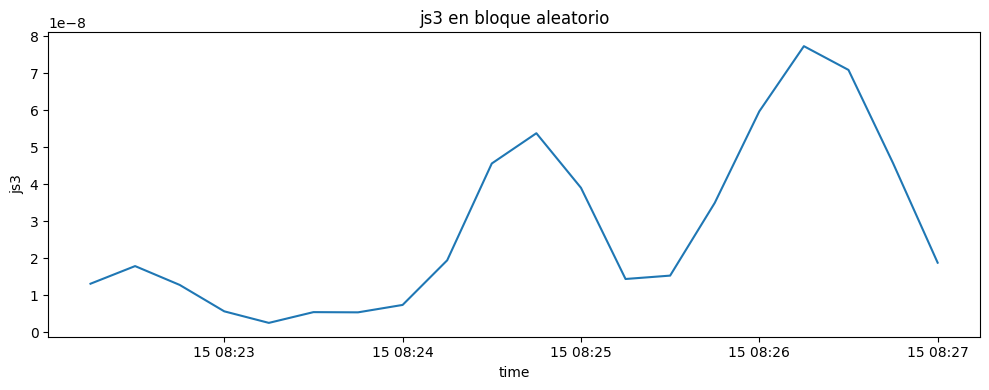

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()

*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"]
df10["dem"] = df10["j2"]
df10["del"] = df10["j3"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 204
des Nulls: 25
dem Ceros: 0
dem Nulls: 25
del Ceros: 0
del Nulls: 25


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Signature Plot***

/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


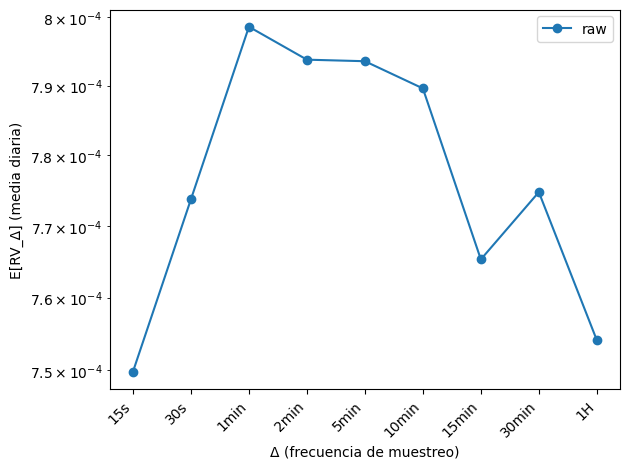

In [ ]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df10)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()
/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


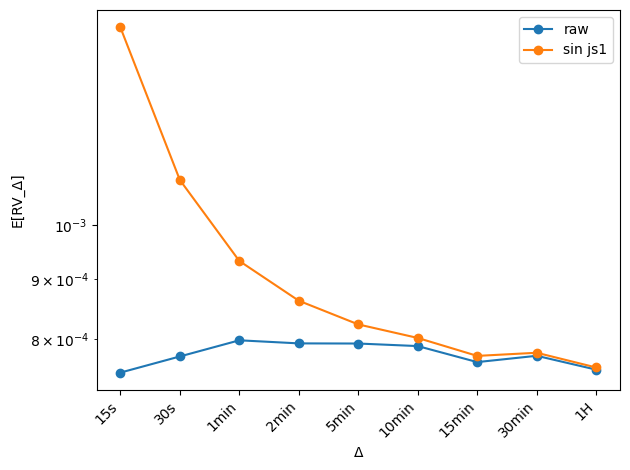

In [ ]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df15)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.028906349166752332), np.float64(-0.3383637881490195))

####SHAP

**HF**

R2 Score: 0.9207
MSE: 0.036014


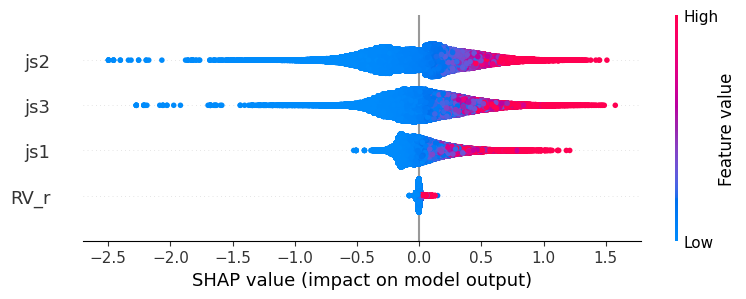

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].shift(-1) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**1 min**

R2 Score: 0.9222
MSE: 0.030751


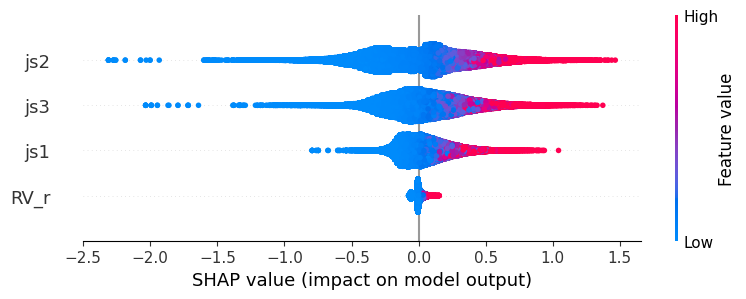

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=8).mean().shift(-4) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

R2 Score: 0.6238
MSE: 0.170948


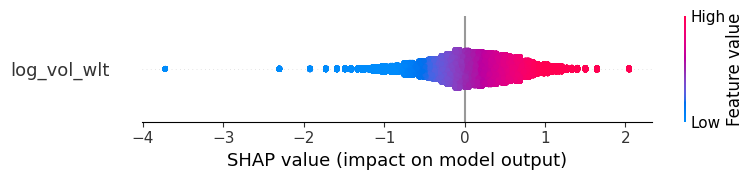

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

#NAVIE

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["log_vol_wlt"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].shift(-4) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**2 min**

R2 Score: 0.7499
MSE: 0.098796


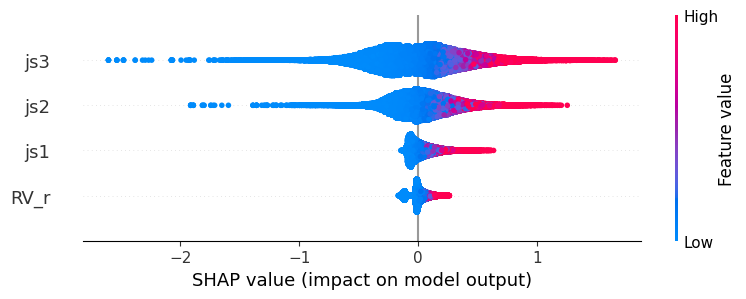

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=8).mean().shift(-8) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**5 min**

R2 Score: 0.6649
MSE: 0.115202


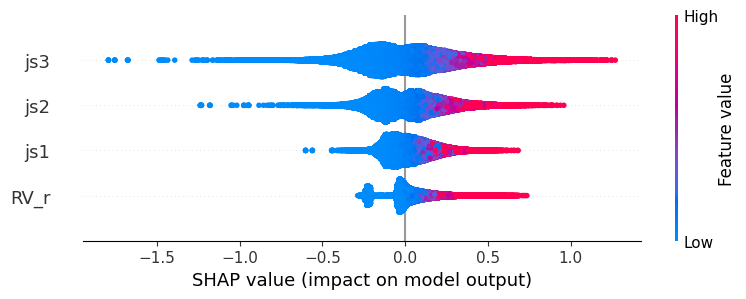

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=20).mean().shift(-20) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

In [ ]:
# TOP HORIZONTES
# 1 MINUTO
# 2 MINUTOS

#### SHAP REGIMENES

Preparación mínima (robusta)

In [ ]:
import numpy as np
import pandas as pd

s = df15["RV_r"].astype(float).clip(lower=1e-12)
lv = np.log(s)

Definir umbrales de ALTA y BAJA volatilidad

In [ ]:
q_low  = lv.quantile(0.25)
q_high = lv.quantile(0.75)

Estados persistentes (priorizar secuencias largas)

In [ ]:
state = pd.Series(
    np.where(lv >= q_high,  1,
    np.where(lv <= q_low,  -1, 0)),
    index=df15.index
)
#  1 = alta, -1 = baja, 0 = neutro

In [ ]:
MIN_LEN = 40   # ~10 minutos si df15 es 15s

grp = (state != state.shift()).cumsum()
segments = state.groupby(grp)

valid_segments = segments.filter(lambda x: len(x) >= MIN_LEN)

dfs

In [ ]:
df_high_vol = df15.loc[valid_segments[valid_segments == 1].index].copy()

In [ ]:
df_low_vol = df15.loc[valid_segments[valid_segments == -1].index].copy()

Violents transitions

In [ ]:
dlv = lv.diff()
jump_thr = dlv.abs().quantile(0.90)

In [ ]:
mask_bh = (
    (lv.shift(1) <= q_low) &
    (lv >= q_high) &
    (dlv >= jump_thr)
)

idx_bh = df15.index[mask_bh]

In [ ]:
W_PRE  = 80   # antes (~20 min)
W_POST = 80   # después

def extract_windows(idx, df, pre, post):
    out = []
    for i in idx:
        p = df.index.get_loc(i)
        a = max(0, p - pre)
        b = min(len(df), p + post)
        out.append(df.iloc[a:b])
    return pd.concat(out).sort_index().drop_duplicates()

df_baja_alta = extract_windows(idx_bh, df15, W_PRE, W_POST)

In [ ]:
mask_hb = (
    (lv.shift(1) >= q_high) &
    (lv <= q_low) &
    (dlv <= -jump_thr)
)

idx_hb = df15.index[mask_hb]

df_alta_baja = extract_windows(idx_hb, df15, W_PRE, W_POST)


**SHAP**

**MODELO ANTERIOR**

HIGH VOLATILITY

In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_hv = df_high_vol.copy()
df_hv["target_future"] = df_hv["log_vol_wlt"].shift(-4)

df_hv = df_hv[expected + ["target_future"]].dropna()

X_hv = df_hv[expected]
y_hv = df_hv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.2715
MSE: 0.395580


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_lv = df_low_vol.copy()
df_lv["target_future"] = df_lv["log_vol_wlt"].shift(-4)

df_lv = df_lv[expected + ["target_future"]].dropna()

X_hv = df_lv[expected]
y_hv = df_lv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.5331
MSE: 2.253817


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_lhv = df_baja_alta.copy()
df_lhv["target_future"] = df_lhv["log_vol_wlt"].shift(-4)

df_lhv = df_lhv[expected + ["target_future"]].dropna()

X_hv = df_lhv[expected]
y_hv = df_lhv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH-LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH-LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.6678
MSE: 0.191213


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_hlv = df_alta_baja.copy()
df_hlv["target_future"] = df_hlv["log_vol_wlt"].shift(-4)

df_hlv = df_hlv[expected + ["target_future"]].dropna()

X_hv = df_hlv[expected]
y_hv = df_hlv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH-LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH-LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.6623
MSE: 0.190564


**MODELOS AJUSTADOS**

In [ ]:
features = ["js1","js2","js3","RV_r"]
target = "log_vol_wlt"

df = df_hv.copy()
df["target_future"] = df[target].shift(-4)
df = df[features + ["target_future"]].dropna()

X, y = df[features], df["target_future"]

# split temporal
n = len(df); tr = int(n*0.7); va = int(n*0.2)
X_train, y_train = X.iloc[:tr], y.iloc[:tr]
X_val, y_val     = X.iloc[tr:tr+va], y.iloc[tr:tr+va]
X_test, y_test   = X.iloc[tr+va:], y.iloc[tr+va:]

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500, max_depth=6, learning_rate=0.05,
    tree_method="hist", early_stopping_rounds=50
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

In [ ]:
import shap
from sklearn.metrics import r2_score, mean_squared_error

# Predicciones test
y_pred = model.predict(X_test)

# Métricas
print(f"R2:  {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# SHAP beeswarm
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bee")

####Blocks minutes

15 minutes

In [ ]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-3233109994.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-3233109994.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.43058979105791767
Spearman: 0.7876467959899837
Kendall : 0.5951426588259752


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.7876467959899837
Kendall : 0.5951426588259752


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


5 minutes

In [ ]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-304541807.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-304541807.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4536667369576258
Spearman: 0.7817484109407691
Kendall : 0.5892922856151096


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.7817484109407691
Kendall : 0.5892922856151096


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


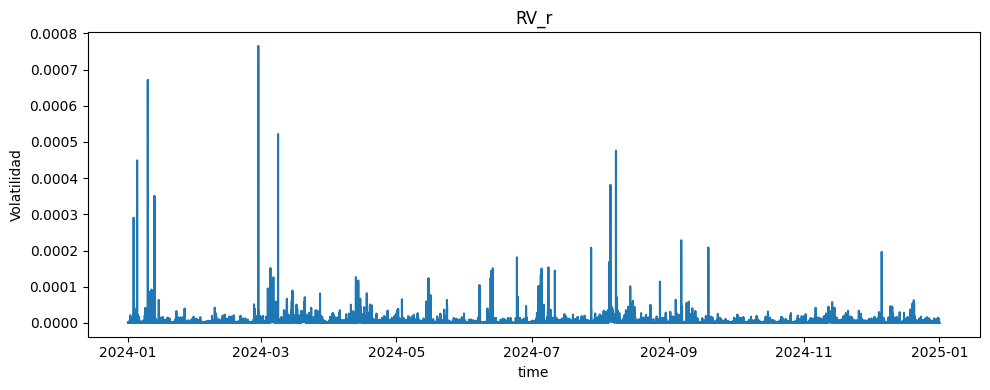

In [ ]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

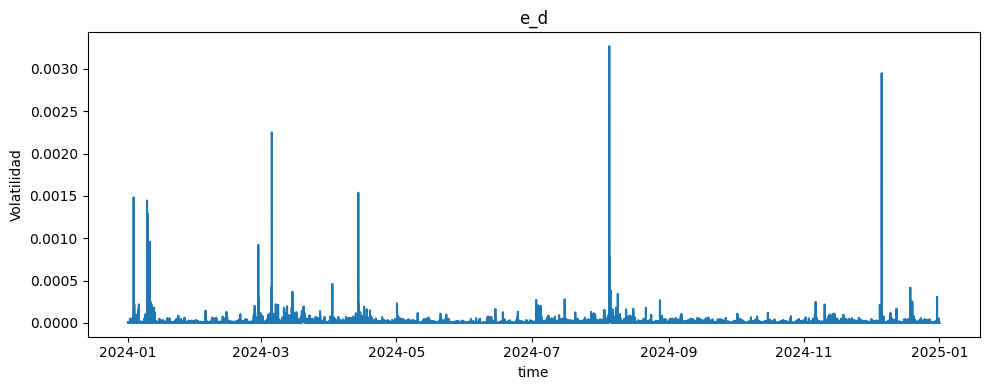

In [ ]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

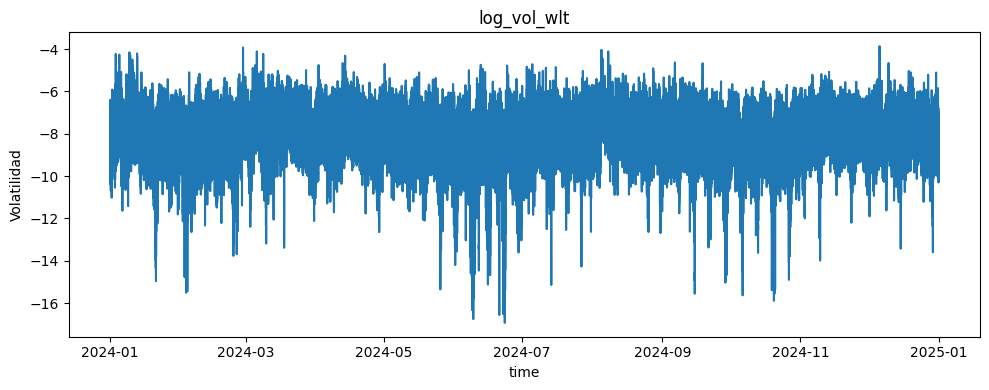

In [ ]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [ ]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(0.009346382080625977), np.float64(0.0037274259736032457))

In [ ]:
#no hay leakage

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   54999.562312        0.0
 10  73851.169901        0.0
 20  92422.459761        0.0,
 'js2':          lb_stat  lb_pvalue
 5   49174.384471        0.0
 10  62040.193222        0.0
 20  74858.937948        0.0,
 'js3':          lb_stat  lb_pvalue
 5   35530.265008        0.0
 10  44092.392903        0.0
 20  51618.090716        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [ ]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.4119542112895267),
 'js2': np.float64(0.4066213093031348),
 'js3': np.float64(0.4400764387086965)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [ ]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.2973378807779419)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

## r_15 **


In [ ]:
df15 = btc.iloc[:, [0, 1, 5, 12]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


Media: 3.76809916230909e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00036078789699599685
Skew: -0.5918241943710671
Deciles:
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
d5 : 0.0
d6 : 2.3319833459822805e-07
d7 : 8.111270573536418e-05
d8 : 0.00017403621973635124
d9 : 0.0003386397390165995
Percentiles mas altos:
d95 : 0.000516697122034948
d96 : 0.0005783330969144623
d97 : 0.0006613860042640953
d98 : 0.0007849116275486496
d99 : 0.00102082375687722
d100 : 0.019740671452751712
Permiles
p970 : 0.0006613860042640953
p971 : 0.0006712843939121873
p972 : 0.0006818457931035193
p973 : 0.0006923294869505018
p974 : 0.0007035229648896201
p975 : 0.000715536563801589
p976 : 0.0007285188955464288
p977 : 0.0007417317042810429
p978 : 0.0007551259786533746
p979 : 0.0007697478319800725
p980 : 0.0007849116275486496
p981 : 0.0008006253623015165
p982 : 0.0008188651597057585
p983 : 0.0008375312170303781
p984 : 0.0008576397359220929
p985 : 0.000

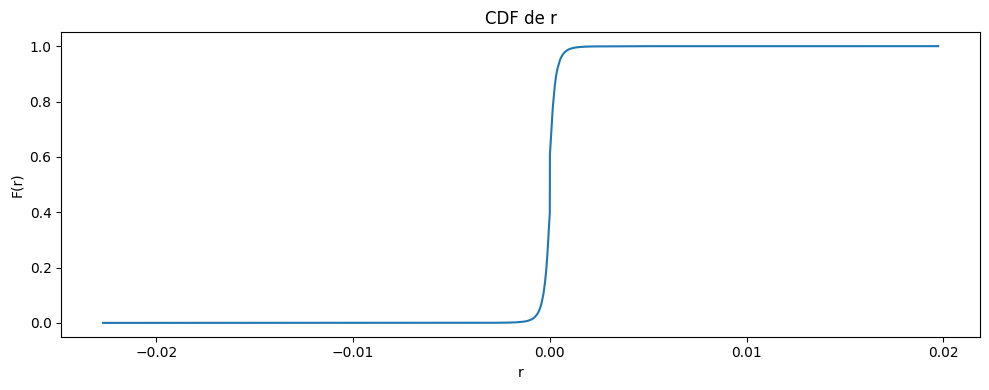

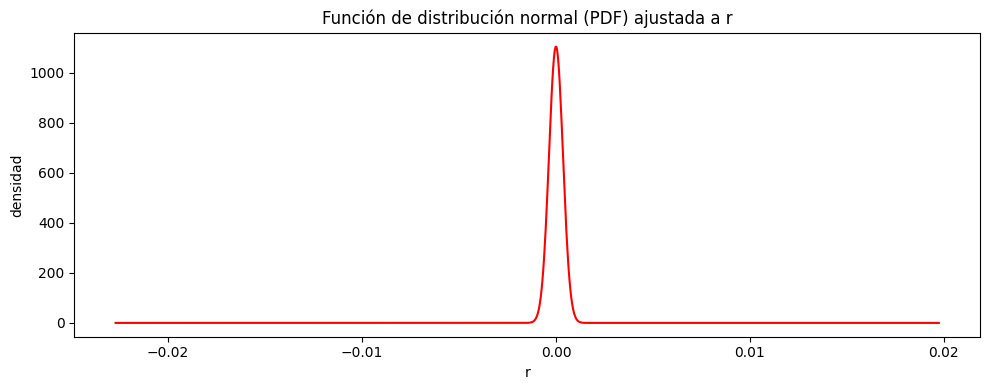

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df15["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df15["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


wavelet

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.984283          0.015717        0.010111   
1    sym6  6      0.984193          0.015807        0.027775   
2    sym4  6      0.984177          0.015823        0.029308   
3     db6  6      0.984326          0.015674        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        1.330457   430.287597  
1             0.004873        1.326638  1241.829204  
2             0.004746        1.323769  1270.757320  
3             0.005486        1.324153  1573.084635  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0044936  0.0090157  0.01846812 0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.0166367  0.03337887 0.06837465 0.12800108 0.26565086 0.48795784]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.984283          0.015717        0.010111   
1    sym6  6      0.984193          0.015807        0.027775   
2    sym4  6      0.984177          0.015823        0.029308   
3     db6  6      0.984326          0.015674        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        1.330457   430.287597  
1             0.004873        1.326638  1241.829204  
2             0.004746        1.323769  1270.757320  
3             0.005486        1.324153  1573.084635  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0044936  0.0090157  0.01846812 0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.0166367  0.03337887 0.06837465 0.12800108 0.26565086 0.48795784]


###vnp teorica

In [ ]:
df15["RV_r"] = df15["r"]**2

Energia local suavizada

In [ ]:
import numpy as np, pywt

x = df15["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)  # si tenés NaN, swt revienta; mejor imputación simple

J = 6
w = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

coeffs = pywt.swt(xp, w, level=J, trim_approx=False)

# Detalles por nivel
for j in range(1, J + 1):
    df15[f"j{j}"] = coeffs[J - j][1][:n]   # cDj
df15[f"a{J}"] = coeffs[-1][0][:n]          # cAJ

In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 34 columns):
 #   Column        Dtype         
---  ------        -----         
 0   time          datetime64[ns]
 1   day           int64         
 2   close         float64       
 3   close_ln      float64       
 4   r             float64       
 5   j1            float64       
 6   j2            float64       
 7   j3            float64       
 8   j4            float64       
 9   j5            float64       
 10  j6            float64       
 11  a6            float64       
 12  js1           float64       
 13  js2           float64       
 14  js3           float64       
 15  js4           float64       
 16  js5           float64       
 17  js6           float64       
 18  es            float64       
 19  em            float64       
 20  el            float64       
 21  e_total       float64       
 22  ers           float64       
 23  erm           float64       
 2

Bloque elegido:
Inicio: 2024-02-24 15:05:01
Fin   : 2024-02-24 15:10:01


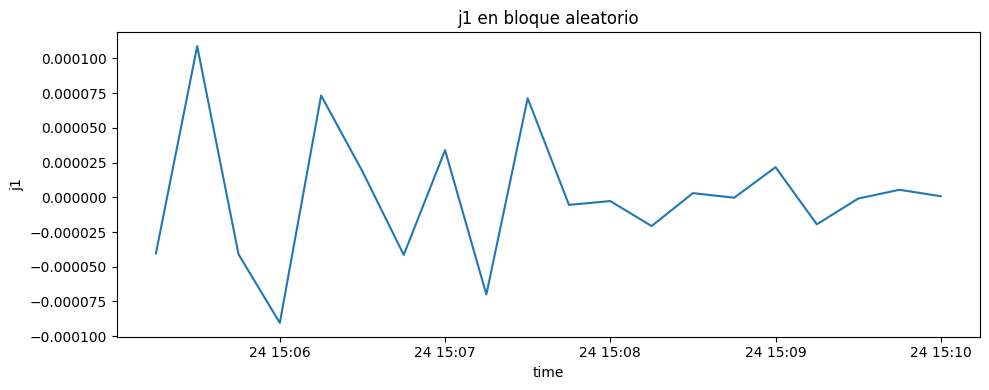

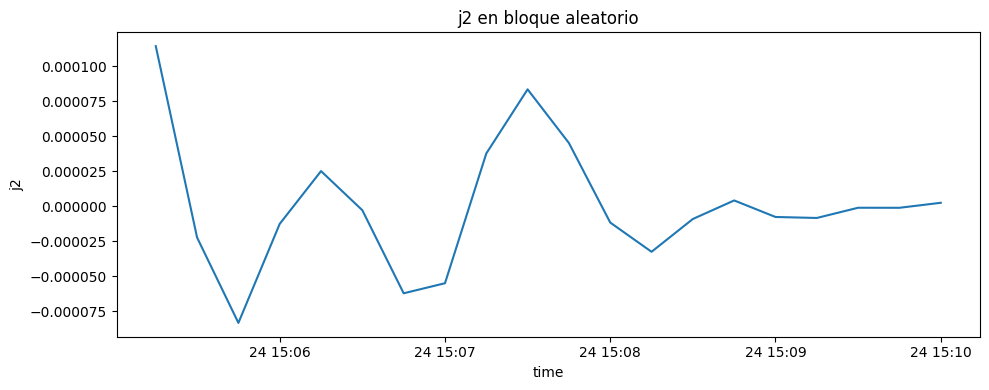

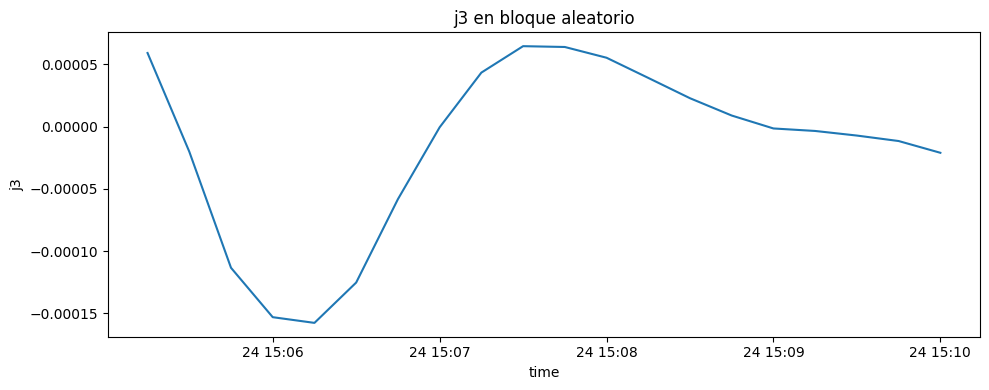

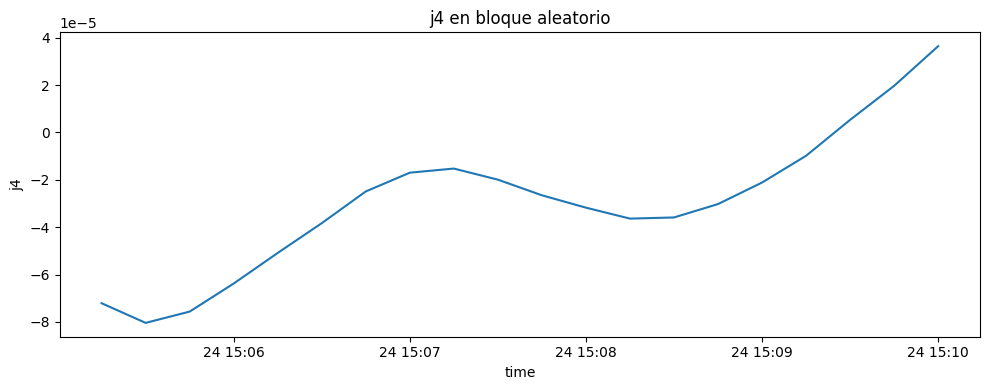

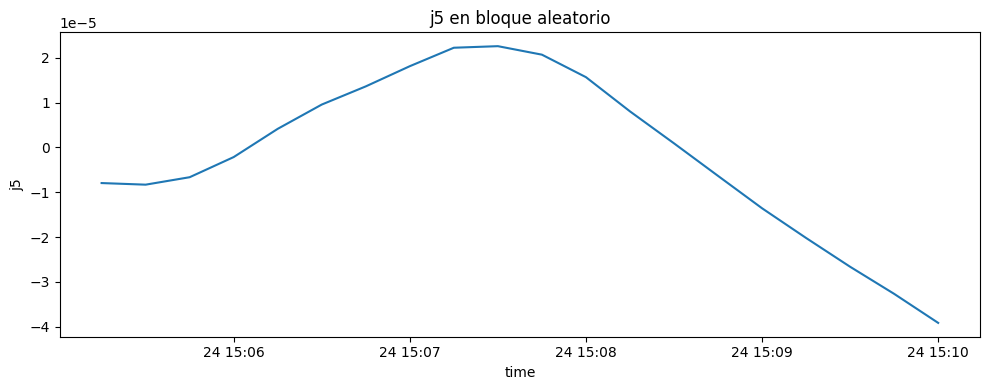

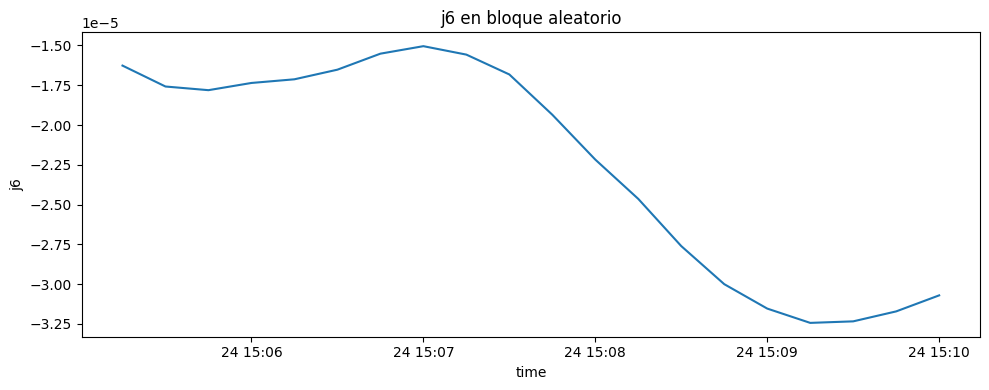

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

In [ ]:
for j in range(1, 7):
    c = df15[f"j{j}"]
    df15[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

Bloque elegido:
Inicio: 2024-12-11 05:31:04
Fin   : 2024-12-11 05:36:04


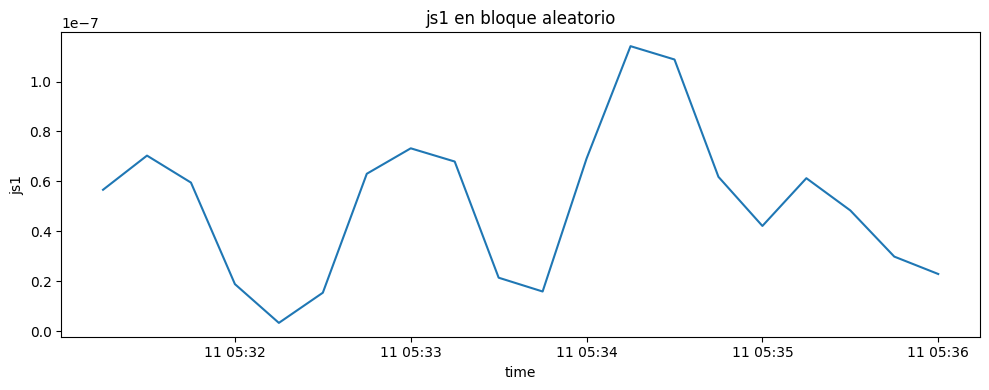

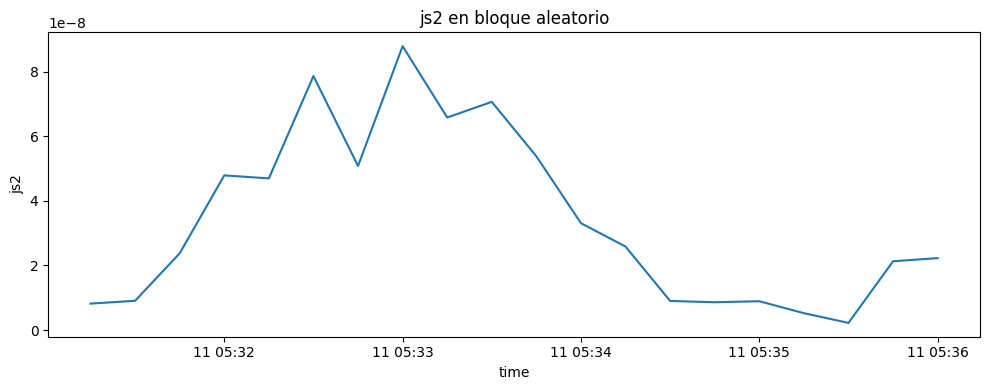

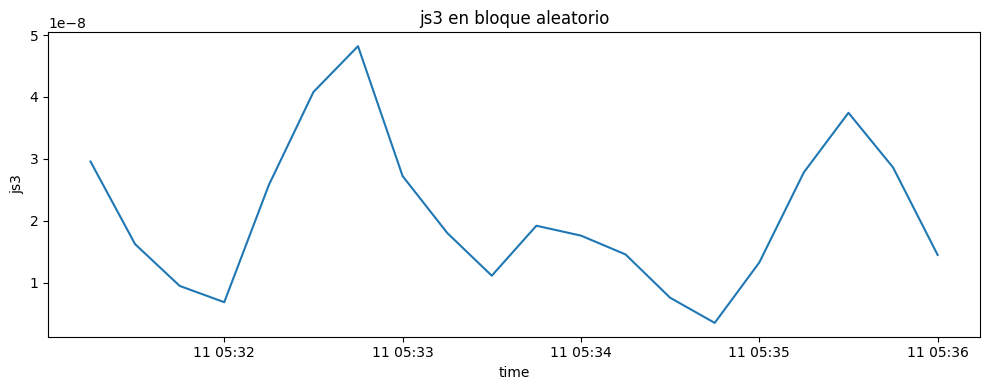

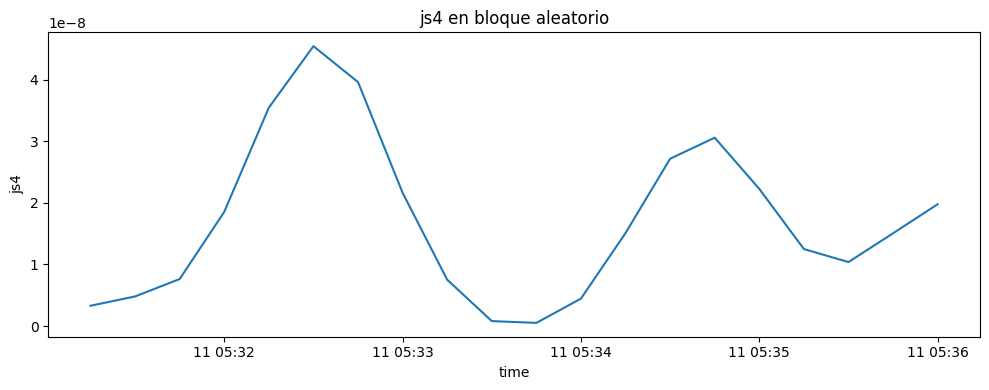

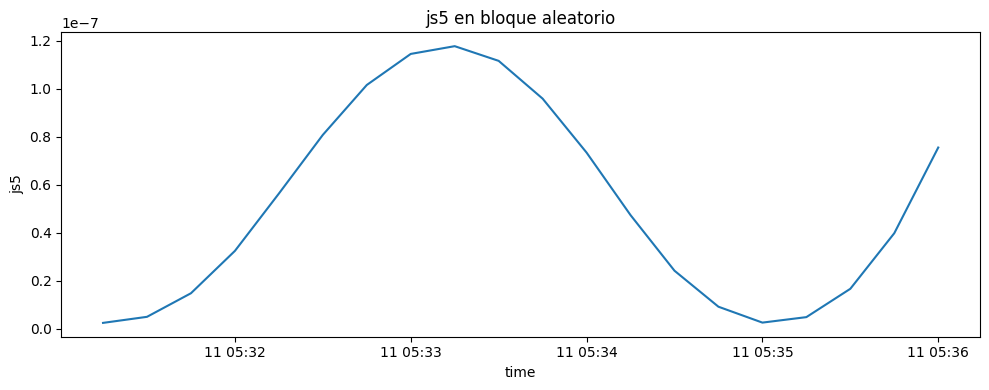

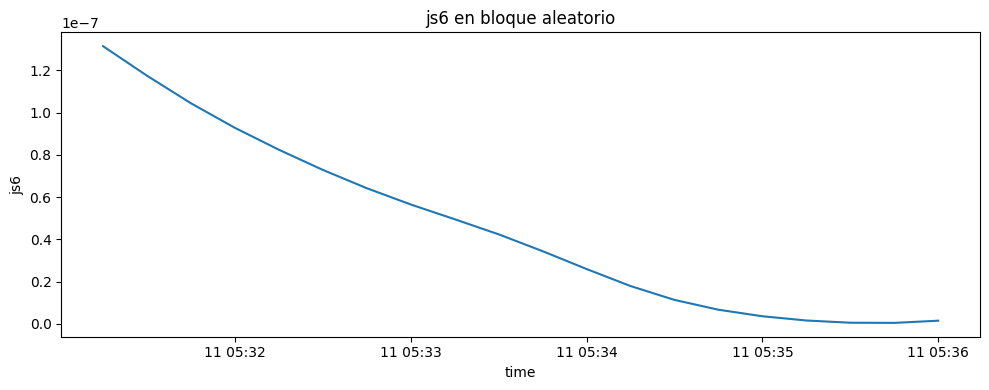

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df15["des"] = df15["j1"] + df15["j2"]
df15["dem"] = df15["j3"] + df15["j4"]
df15["del"] = df15["j5"] + df15["j6"]

In [ ]:
s = df15["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df15["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df15["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 0
dem Ceros: 0
dem Nulls: 0
del Ceros: 0
del Nulls: 0


In [ ]:
df15["de_total"] = df15["des"] + df15["dem"] + df15["del"]

In [ ]:
df15["dvol_wlt"] = np.sqrt(df15["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df15["dlog_vol_wlt"] = np.log(df15["dvol_wlt"])

***Eshort, Emedium and ELong all clean***

In [ ]:
df15["es"] = df15["js1"] + df15["js2"]
df15["em"] = df15["js3"] + df15["js4"]
df15["el"] = df15["js5"] + df15["js6"]

In [ ]:
s = df15["es"]
print("es Ceros:", (s == 0).sum())
print("es Nulls:", s.isna().sum())
s = df15["em"]
print("em Ceros:", (s == 0).sum())
print("em Nulls:", s.isna().sum())
s = df15["el"]
print("el Ceros:", (s == 0).sum())
print("el Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

es Ceros: 0
es Nulls: 0
em Ceros: 0
em Nulls: 0
el Ceros: 0
el Nulls: 0


In [ ]:
# dado que no hay ceros va sin epsilon

Bloque elegido:
Inicio: 2024-08-02 13:32:28
Fin   : 2024-08-02 13:37:28


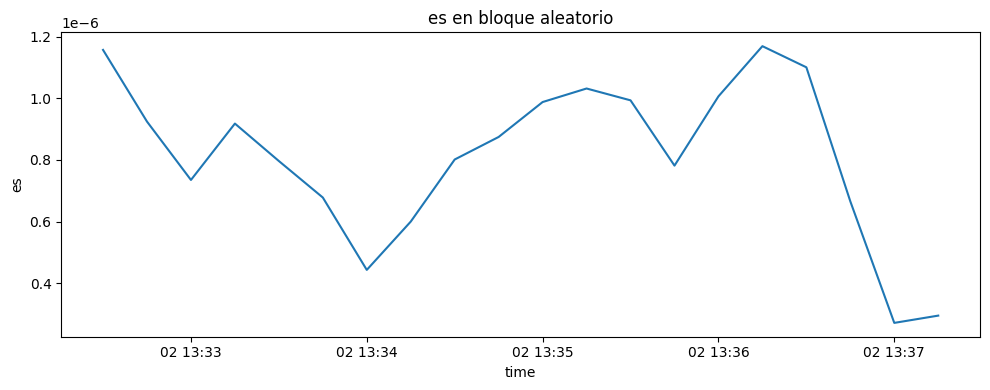

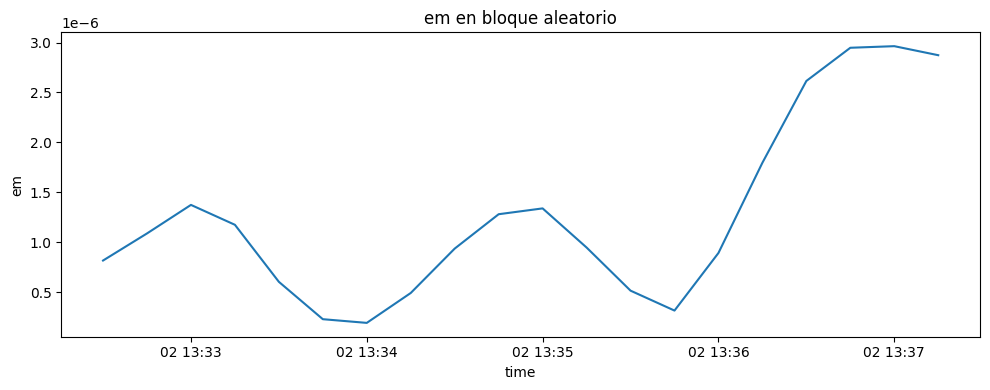

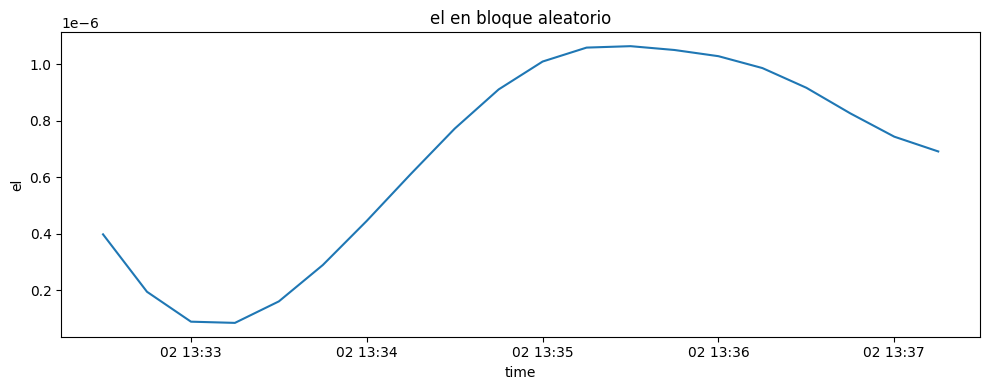

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el"]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em y el
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()


***Energia log-relativa***

In [ ]:
df15["e_total"] = df15["es"] + df15["em"] + df15["el"]
s = df15["e_total"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [ ]:
df15["ers"] = np.log((df15["es"]) / df15["e_total"])
df15["erm"] = np.log((df15["em"]) / df15["e_total"])
df15["erl"] = np.log((df15["el"]) / df15["e_total"])

In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 26 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   j4        float64       
 10  j5        float64       
 11  j6        float64       
 12  a6        float64       
 13  js1       float64       
 14  js2       float64       
 15  js3       float64       
 16  js4       float64       
 17  js5       float64       
 18  js6       float64       
 19  es        float64       
 20  em        float64       
 21  el        float64       
 22  e_total   float64       
 23  ers       float64       
 24  erm       float64       
 25  erl       float64       
dtypes: datetime64[ns](1), float64(24), int64(

Bloque elegido:
Inicio: 2024-07-01 14:11:51
Fin   : 2024-07-01 14:41:51


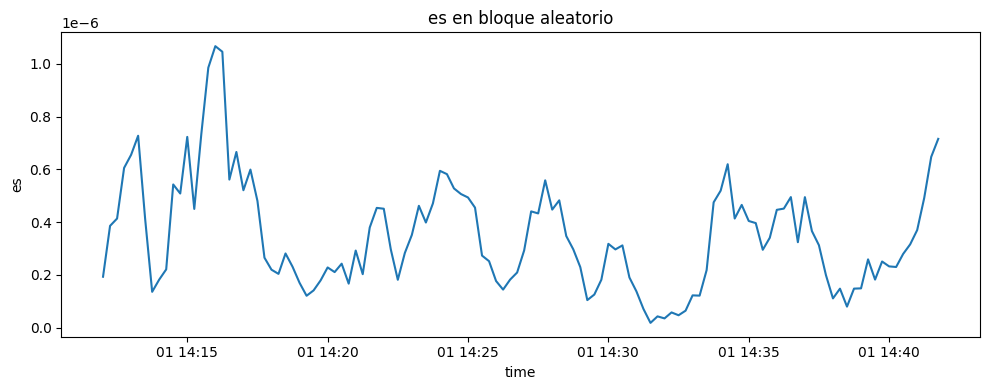

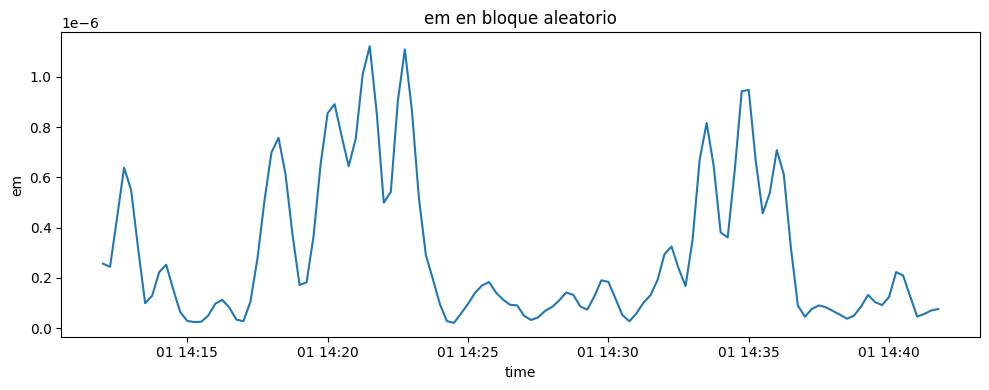

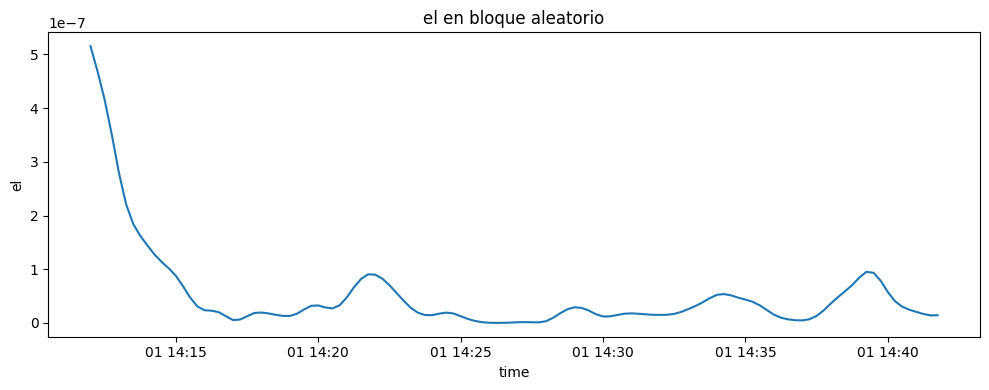

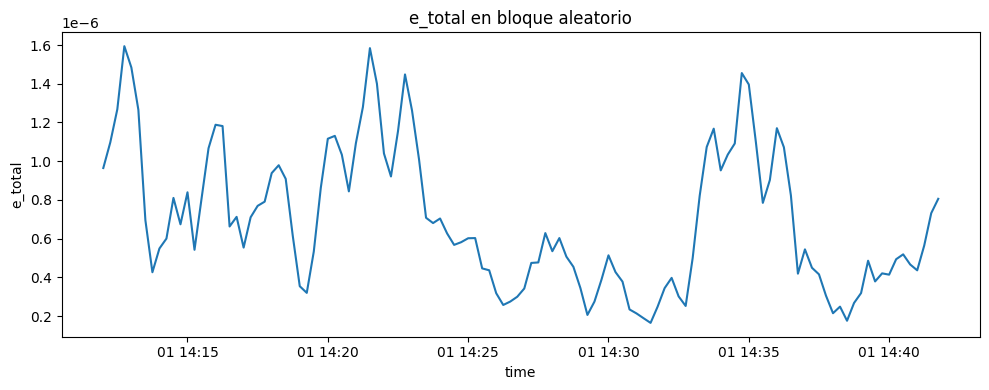

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=30)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el", "e_total"]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em, el y e_total
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()

In [ ]:
df15["vol_wlt"] = np.sqrt(df15["e_total"])

In [ ]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 0


In [ ]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

In [ ]:
import matplotlib.pyplot as plt
# Histograma de_total
plt.figure(figsize=(6,4))
plt.hist(df15["de_total"].dropna(), bins=100)
plt.title("Histograma de_total")
plt.xlabel("de_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dvol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["dvol_wlt"].dropna(), bins=100)
plt.title("Histograma dvol_wlt")
plt.xlabel("dvol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dlog_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["dlog_vol_wlt"].dropna(), bins=100)
plt.title("Histograma dlog_vol_wlt")
plt.xlabel("dlog_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df15["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Individual checks

In [ ]:
import numpy as np
from scipy.stats import skew

s = df15["log_vol_wlt"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)



print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)

Media: -7.462308926273783
Mediana: -7.455560093497798
Moda: -13.653599638206268
Desvío estándar: 0.6596274852434844
Skew: -0.14074585232031617


In [ ]:
# Moda por bindeo (más representativa)
counts, bins = np.histogram(s, bins=100)
moda_real = bins[np.argmax(counts)]
print("moda bins:", moda_real)

moda bins: -7.566874573191112


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

s = df15["log_vol_wlt"].dropna()

# 1) Deciles + permil 0.005 (0.5%)
deciles = s.quantile(np.arange(0.1, 1.0, 0.1)).tolist()
p0005 = s.quantile(0.005)
print("Deciles (0.1..0.9):", deciles)
print("Permil 0.005:", p0005)

# 2) Autocorrelación: primeros 20 lags + gráfica
acf_vals = acf(s.values, nlags=20, fft=True)  # incluye lag 0
print("\nACF primeros 20 lags (lag: valor):")
for lag, val in enumerate(acf_vals[:21]):
    print(f"{lag:>2}: {val:.6f}")

plt.figure(figsize=(10,4))
plot_acf(s, lags=20, zero=True)
plt.title("ACF: log_vol_wlt (0..20 lags)")
plt.tight_layout()
plt.show()

# 3) Top 5 días con más observaciones <= permil 0.005
d = df15.loc[df15["log_vol_wlt"].le(p0005), ["time"]].dropna()
top5 = (d.assign(day=d["time"].dt.date)
         .groupby("day").size()
         .sort_values(ascending=False)
         .head(5))
print("\nTop 5 días con más obs <= permil 0.005:")
print(top5)

In [ ]:
s = df15["log_vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


Realized variance Test

In [ ]:
# Limpieza mínima
s = df15[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16557027358617013
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
# Limpieza mínima
s = df15[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4228209095367485
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
import statsmodels.api as sm

# Datos
y = df15["RV_r"]
X = df15["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Bloques

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-277755125.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,1.139686e-06,0.000004,-0.005786,-7.740164,0.000440
1,2024-01-01 00:05:00,6.450701e-07,0.000005,0.001273,-7.581748,0.000516
2,2024-01-01 00:10:00,7.303034e-07,0.000007,-0.005835,-7.483053,0.000584
3,2024-01-01 00:15:00,1.644573e-06,0.000009,-0.001419,-7.337899,0.000658
4,2024-01-01 00:20:00,3.923958e-07,0.000005,-0.004291,-7.705582,0.000467


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.37654537193217874
Spearman: 0.9138267375567589
Kendall : 0.7538350428694848


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8774666526779349
Spearman: 0.9189316864022443
Kendall : 0.7635214552776779


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 28 columns):
 #   Column       Dtype         
---  ------       -----         
 0   time         datetime64[ns]
 1   day          int64         
 2   close        float64       
 3   close_ln     float64       
 4   r            float64       
 5   RV_r         float64       
 6   j1           float64       
 7   j2           float64       
 8   j3           float64       
 9   j4           float64       
 10  j5           float64       
 11  j6           float64       
 12  a6           float64       
 13  js1          float64       
 14  js2          float64       
 15  js3          float64       
 16  js4          float64       
 17  js5          float64       
 18  js6          float64       
 19  es           float64       
 20  em           float64       
 21  el           float64       
 22  e_total      float64       
 23  ers          float64       
 24  erm          float64   

### VPN productiva j=6

In [ ]:
df15 = btc.iloc[:, [0, 1, 5, 12]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


In [ ]:
df15["RV_r"] = df15["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)

J = 6
w_name = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

# 2. Transformada SWT (Batch)
coeffs = pywt.swt(xp, w_name, level=J, trim_approx=False)

# 3. Cálculo del Desplazamiento (Shift) para db4 en J=6
# Para Daubechies, el soporte del filtro en el nivel J es (2p-1)*(2^J - 1) + 1
p = 4  # Para db4
max_support = (2*p - 1) * (2**J - 1) + 1
shift_size = int(max_support / 2)

# 4. Asignación al DataFrame con alineación causal
for j in range(1, J + 1):
    raw_detail = coeffs[J-j][1][:n]
    df15[f"j{j}"] = pd.Series(raw_detail).shift(shift_size).values
# Aproximación final (a6)
raw_approx = coeffs[-1][0][:n]
df15[f"a{J}"] = pd.Series(raw_approx).shift(shift_size).values

print(f"✅ Features generadas. Shift causal aplicado: {shift_size} filas.")

✅ Features generadas. Shift causal aplicado: 221 filas.


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 13 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   j4        float64       
 10  j5        float64       
 11  j6        float64       
 12  a6        float64       
dtypes: datetime64[ns](1), float64(11), int64(1)
memory usage: 209.1 MB


In [ ]:
for j in range(1, 7):
    c = df15[f"j{j}"]
    df15[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df15["es"] = df15["js1"] + df15["js2"]
df15["em"] = df15["js3"] + df15["js4"]
df15["el"] = df15["js5"] + df15["js6"]

In [ ]:
df15["e_d"] = df15["es"] + df15["em"] + df15["el"]
s = df15["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 221


In [ ]:
df15["ers"] = np.log((df15["es"]) / df15["e_d"])
df15["erm"] = np.log((df15["em"]) / df15["e_d"])
df15["erl"] = np.log((df15["el"]) / df15["e_d"])

In [ ]:
df15["vol_wlt"] = np.sqrt(df15["e_d"])

In [ ]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 221


In [ ]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

In [ ]:
df15["as6"] = (df15["a6"] * df15["a6"]).rolling(3, min_periods=1).mean()
df15["e_total"] = df15["es"] + df15["em"] + df15["el"] + df15["as6"]

In [ ]:
df15["ers"] = np.log((df15["es"]) / df15["e_total"])
df15["erm"] = np.log((df15["em"]) / df15["e_total"])
df15["erl"] = np.log((df15["el"]) / df15["e_total"])

In [ ]:
df15["vol_wlt"] = np.sqrt(df15["e_total"])

In [ ]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 221


In [ ]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

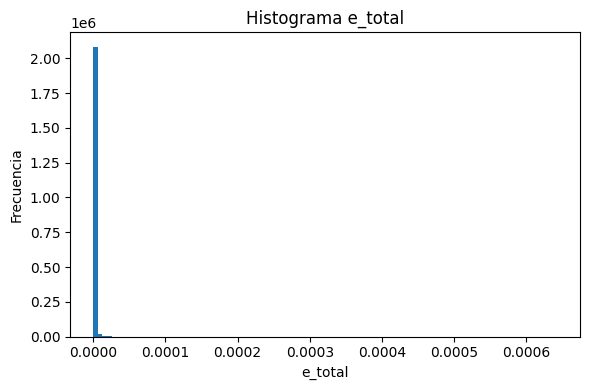

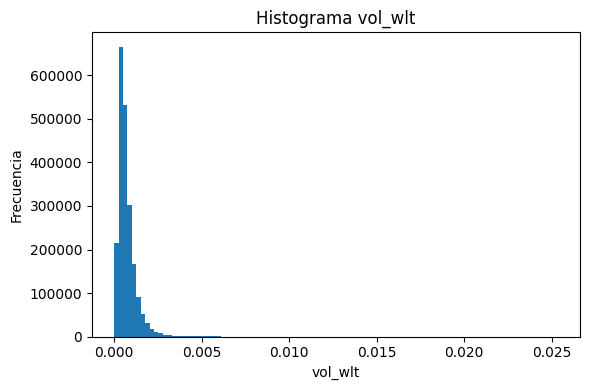

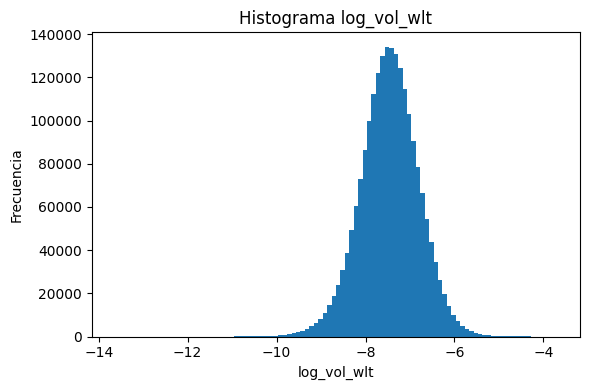

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df15["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- preparar y alinear ---
y = df15["y_fut"]

A = pd.concat([y, XA.add_prefix("A_")], axis=1).dropna()
B = pd.concat([y, XB.add_prefix("B_")], axis=1).dropna()

yA = A["y_fut"].to_numpy()
XA_ = A.drop(columns="y_fut").to_numpy()

yB = B["y_fut"].to_numpy()
XB_ = B.drop(columns="y_fut").to_numpy()

# --- split temporal (80/20) ---
def split_time(X, y, frac=0.8):
    n = len(y)
    k = int(n * frac)
    return X[:k], y[:k], X[k:], y[k:]

XA_tr, yA_tr, XA_te, yA_te = split_time(XA_, yA)
XB_tr, yB_tr, XB_te, yB_te = split_time(XB_, yB)

# --- modelo base ---
mdl = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# A
mdl.fit(XA_tr, yA_tr)
predA = mdl.predict(XA_te)

# B
mdl.fit(XB_tr, yB_tr)
predB = mdl.predict(XB_te)

# --- métricas ---
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": np.sqrt(mse),
        "mae":  mean_absolute_error(y_true, y_pred),
        "corr": np.corrcoef(y_true, y_pred)[0, 1],
    }

out = pd.DataFrame([
    {"model": "A (j)", **metrics(yA_te, predA)},
    {"model": "B (j shift+1)", **metrics(yB_te, predB)}
])

print(out)

           model      rmse       mae      corr
0          A (j)  0.624945  0.492754  0.008179
1  B (j shift+1)  0.624933  0.492750  0.010338


Bloque elegido:
Inicio: 2024-01-09 02:13:32
Fin   : 2024-01-09 02:18:32


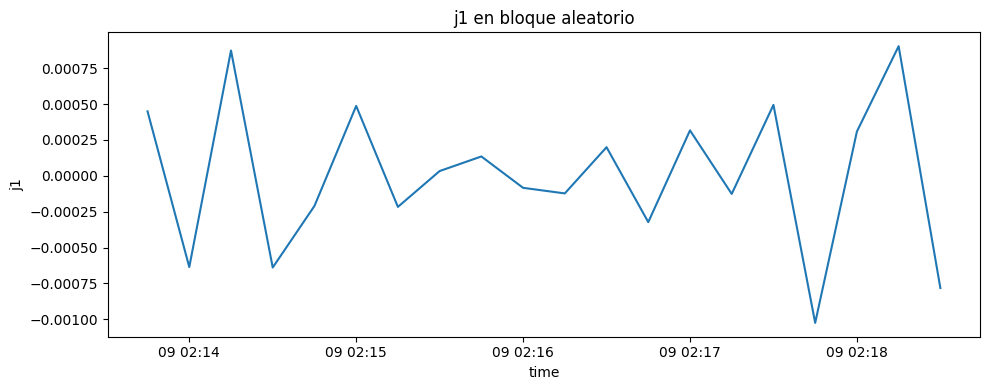

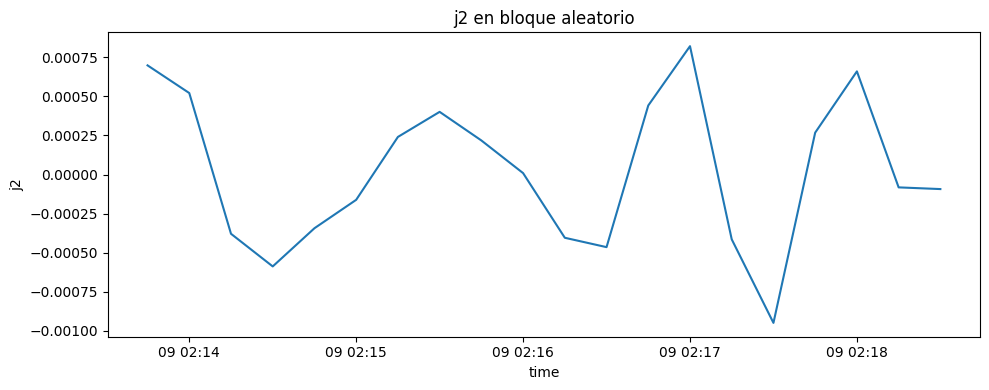

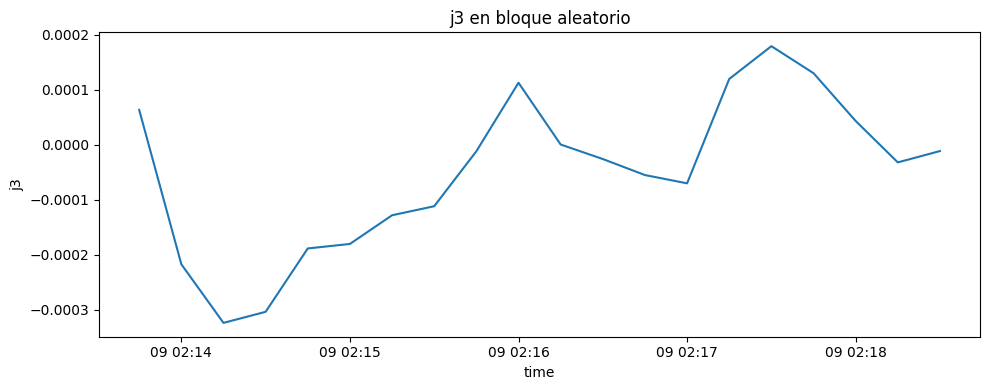

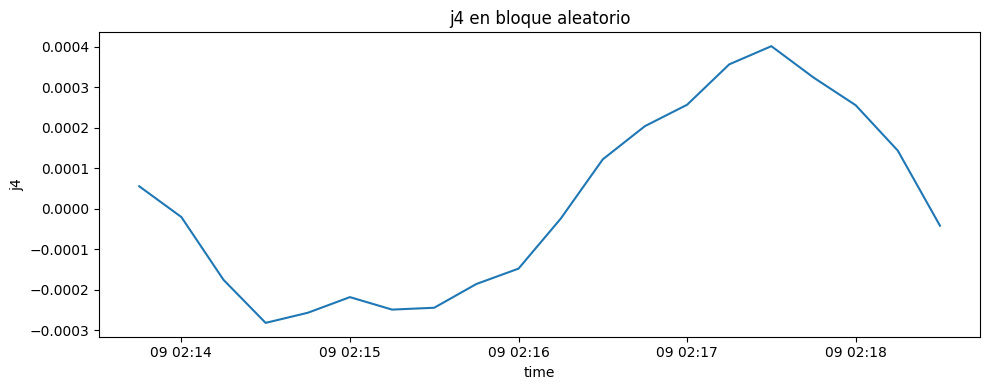

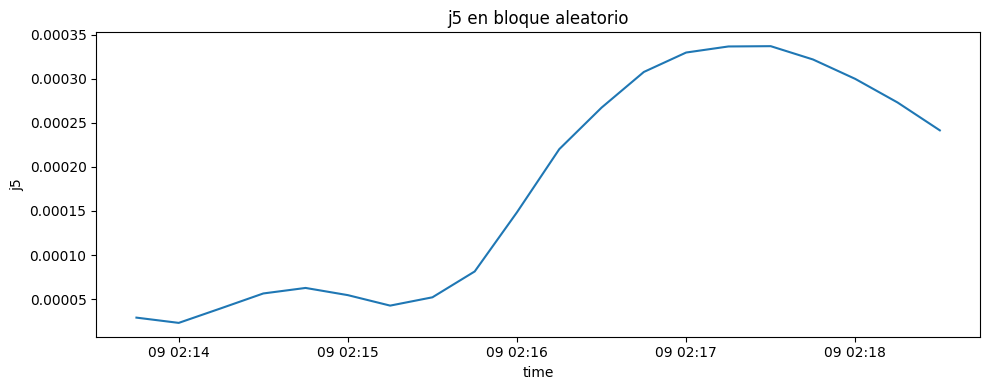

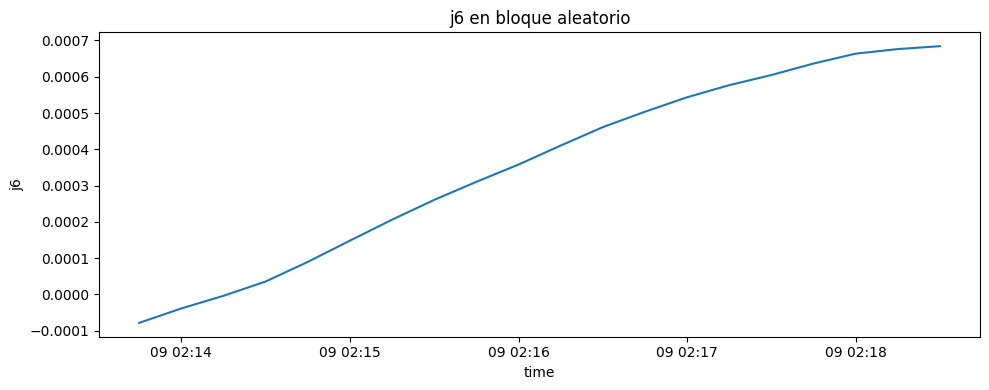

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-12-11 05:31:04
Fin   : 2024-12-11 05:36:04


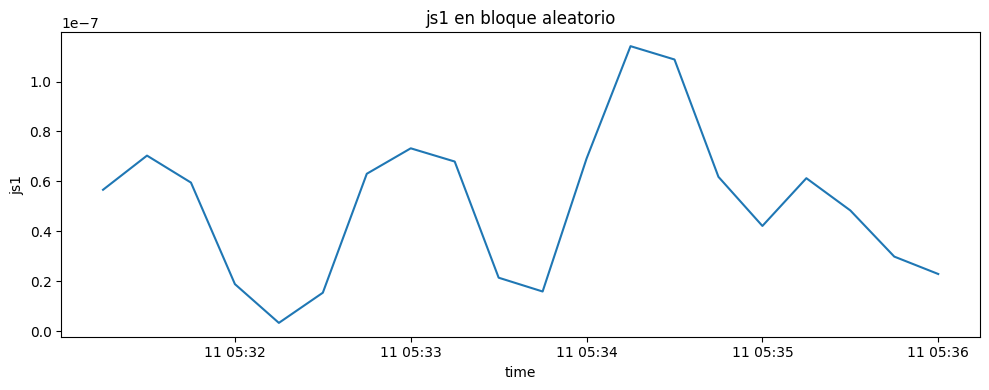

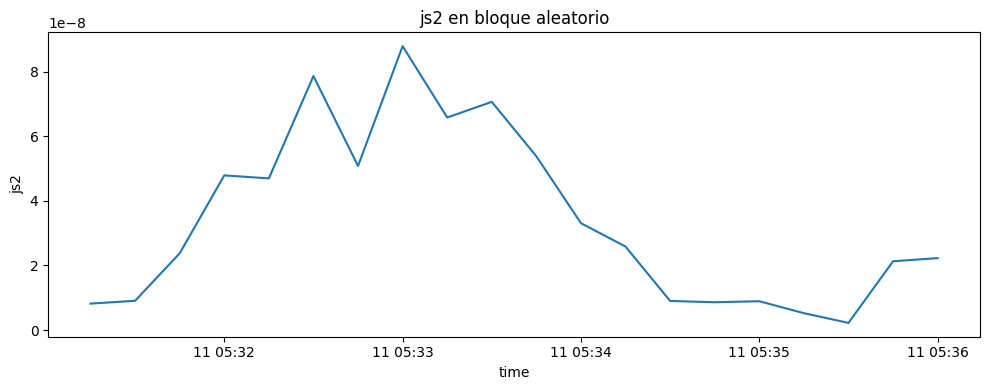

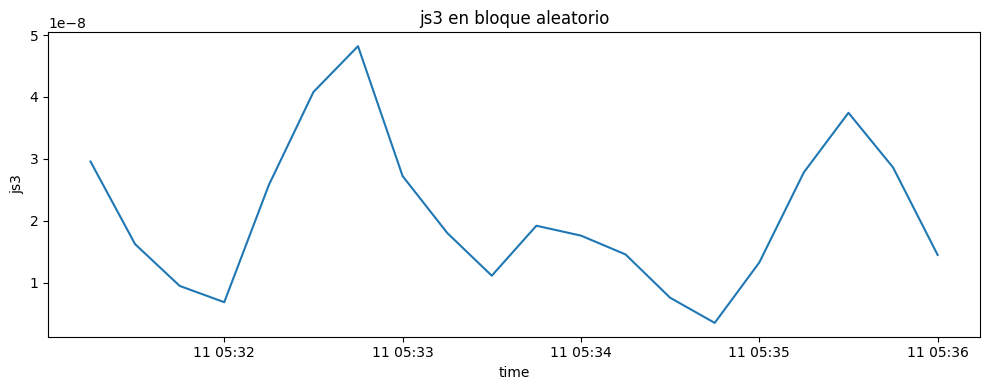

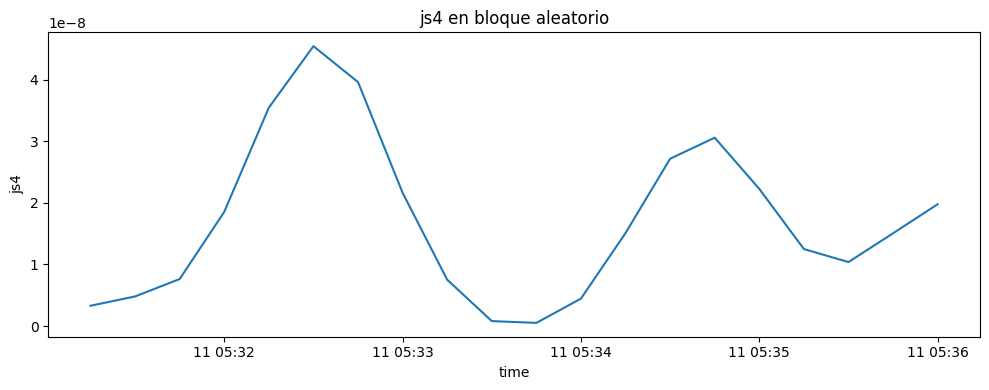

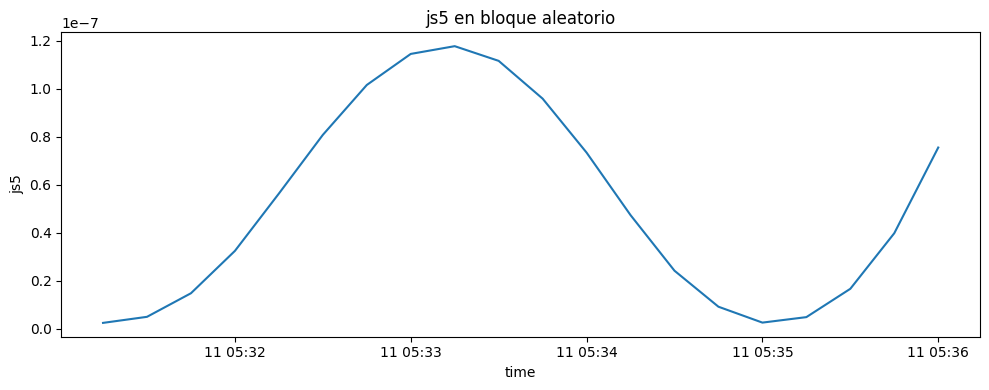

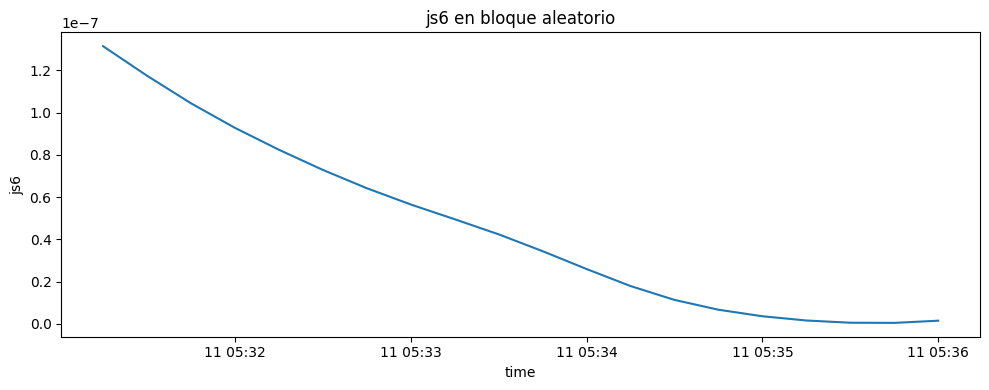

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df15["des"] = df15["j1"] + df15["j2"]
df15["dem"] = df15["j3"] + df15["j4"]
df15["del"] = df15["j5"] + df15["j6"]

In [ ]:
s = df15["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df15["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df15["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 221
dem Ceros: 0
dem Nulls: 221
del Ceros: 0
del Nulls: 221


In [ ]:
df15["de_total"] = df15["des"] + df15["dem"] + df15["del"]

In [ ]:
df15["dvol_wlt"] = np.sqrt(df15["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df15["dlog_vol_wlt"] = np.log(df15["dvol_wlt"])

Bloques

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "e_d": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-3438224154.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,e_d,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,1.139686e-06,0.0,0.0,0.0,NaN,NaN
1,2024-01-01 00:05:00,6.450701e-07,0.0,0.0,0.0,NaN,NaN
2,2024-01-01 00:10:00,7.303034e-07,0.0,0.0,0.0,NaN,NaN
3,2024-01-01 00:15:00,1.644573e-06,0.0,0.0,0.0,NaN,NaN
4,2024-01-01 00:20:00,3.923958e-07,0.0,0.0,0.0,NaN,NaN


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.21544873881701299
Spearman: 0.6477239010806094
Kendall : 0.4663506745181907


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.2518850720506713
Spearman: 0.6487476393813625
Kendall : 0.46731306285731394


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.17189119587183604
Spearman: 0.647109274928379
Kendall : 0.46587777547255893


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16997236725839932
Spearman: 0.6480173518943156
Kendall : 0.46669977393347556


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : -0.009021164186352258
Spearman: -0.0002881349693539902
Kendall : -0.00019413898680459545


15 minutos

In [ ]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df15m = df15_.resample("15T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "e_d": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df15m.head()

/tmp/ipython-input-4063059535.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df15_.resample("15T").agg({


,time,RV_r,e_total,e_d,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,2.515060e-06,0.000000,0.000000,0.000000,NaN,NaN
1,2024-01-01 00:15:00,3.713050e-06,0.000000,0.000000,0.000000,NaN,NaN
2,2024-01-01 00:30:00,2.601648e-06,0.000000,0.000000,0.000000,NaN,NaN
3,2024-01-01 00:45:00,8.700969e-07,0.000005,0.000004,-0.005631,-7.593867,0.000509
4,2024-01-01 01:00:00,1.206592e-06,0.000025,0.000021,-0.005785,-7.379522,0.000636


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.2909808305897285
Spearman: 0.7254005108930094
Kendall : 0.5376808996974943


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.3416549600855191
Spearman: 0.7237001647079746
Kendall : 0.5361232689796761


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.24695248643233567
Spearman: 0.7208498307887303
Kendall : 0.5334308783090657


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16997236725839932
Spearman: 0.6480173518943156
Kendall : 0.46669977393347556


In [ ]:
# Limpieza mínima
s = df5m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : -0.009021164186352258
Spearman: -0.0002881349693539902
Kendall : -0.00019413898680459545


### VPN productiva j=3 *

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.867754          0.132246        0.010111   
1    sym6  3      0.867436          0.132564        0.027775   
2    sym4  3      0.867674          0.132326        0.029308   
3     db6  3      0.867601          0.132399        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        0.969032   430.287597  
1             0.004873        0.963715  1241.829204  
2             0.004746        0.961043  1270.757320  
3             0.005486        0.960648  1573.084635  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.14519017 0.30132476 0.55348506]


In [ ]:
df15 = btc.iloc[:, [0, 1, 5, 12]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


In [ ]:
df15["RV_r"] = df15["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)

J = 3
w_name = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

# 2. Transformada SWT (Batch)
coeffs = pywt.swt(xp, w_name, level=J, trim_approx=False)

# 3. Cálculo del Desplazamiento (Shift) para db4 en J=6
# Para Daubechies, el soporte del filtro en el nivel J es (2p-1)*(2^J - 1) + 1
p = 4  # Para db4
max_support = (2*p - 1) * (2**J - 1) + 1
shift_size = int(max_support / 2)

# 4. Asignación al DataFrame con alineación causal
for j in range(1, J + 1):
    raw_detail = coeffs[J-j][1][:n]
    df15[f"j{j}"] = pd.Series(raw_detail).shift(shift_size).values
# Aproximación final (a6)
raw_approx = coeffs[-1][0][:n]
df15[f"a{J}"] = pd.Series(raw_approx).shift(shift_size).values

print(f"✅ Features generadas. Shift causal aplicado: {shift_size} filas.")

✅ Features generadas. Shift causal aplicado: 25 filas.


In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 160.8 MB


In [ ]:
for j in range(1, 4):
    c = df15[f"j{j}"]
    df15[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df15["es"] = df15["js1"]
df15["em"] = df15["js2"]
df15["el"] = df15["js3"]

In [ ]:
df15["e_d"] = df15["es"] + df15["em"] + df15["el"]
s = df15["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 25


In [ ]:
df15["ers"] = np.log((df15["es"]) / df15["e_d"])
df15["erm"] = np.log((df15["em"]) / df15["e_d"])
df15["erl"] = np.log((df15["el"]) / df15["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df15["vol_wlt"] = np.sqrt(df15["e_d"])

In [ ]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 25


In [ ]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

In [ ]:
df15["as3"] = (df15["a3"] * df15["a3"]).rolling(3, min_periods=1).mean()
df15["e_total"] = df15["es"] + df15["em"] + df15["el"] + df15["as3"]

In [ ]:
df15["ers"] = np.log((df15["es"]) / df15["e_total"])
df15["erm"] = np.log((df15["em"]) / df15["e_total"])
df15["erl"] = np.log((df15["el"]) / df15["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df15["tvol_wlt"] = np.sqrt(df15["e_total"])

In [ ]:
s = df15["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 25


In [ ]:
df15["tlog_vol_wlt"] = np.log(df15["tvol_wlt"])

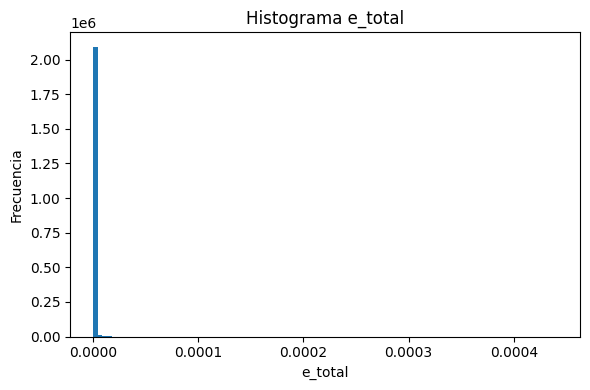

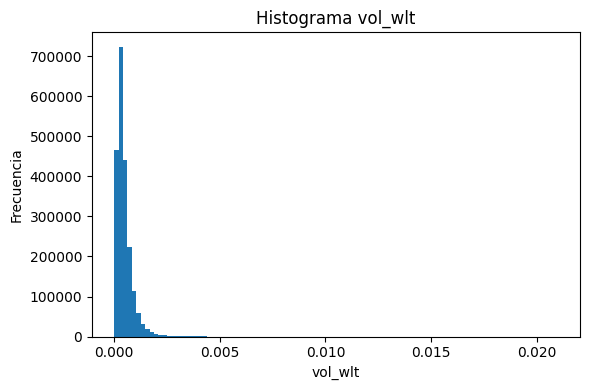

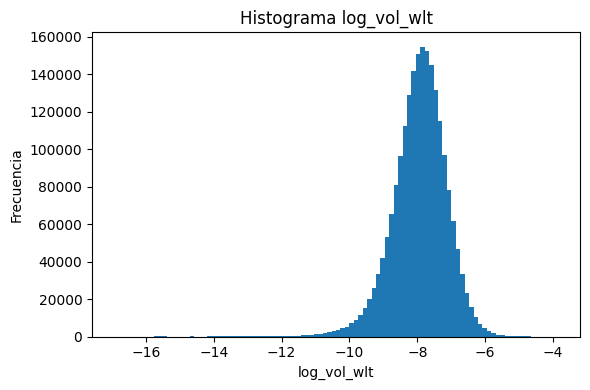

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df15["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- preparar y alinear ---
y = df15["y_fut"]

A = pd.concat([y, XA.add_prefix("A_")], axis=1).dropna()
B = pd.concat([y, XB.add_prefix("B_")], axis=1).dropna()

yA = A["y_fut"].to_numpy()
XA_ = A.drop(columns="y_fut").to_numpy()

yB = B["y_fut"].to_numpy()
XB_ = B.drop(columns="y_fut").to_numpy()

# --- split temporal (80/20) ---
def split_time(X, y, frac=0.8):
    n = len(y)
    k = int(n * frac)
    return X[:k], y[:k], X[k:], y[k:]

XA_tr, yA_tr, XA_te, yA_te = split_time(XA_, yA)
XB_tr, yB_tr, XB_te, yB_te = split_time(XB_, yB)

# --- modelo base ---
mdl = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# A
mdl.fit(XA_tr, yA_tr)
predA = mdl.predict(XA_te)

# B
mdl.fit(XB_tr, yB_tr)
predB = mdl.predict(XB_te)

# --- métricas ---
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": np.sqrt(mse),
        "mae":  mean_absolute_error(y_true, y_pred),
        "corr": np.corrcoef(y_true, y_pred)[0, 1],
    }

out = pd.DataFrame([
    {"model": "A (j)", **metrics(yA_te, predA)},
    {"model": "B (j shift+1)", **metrics(yB_te, predB)}
])

print(out)

           model      rmse       mae      corr
0          A (j)  0.624945  0.492754  0.008179
1  B (j shift+1)  0.624933  0.492750  0.010338


Bloque elegido:
Inicio: 2024-02-01 04:52:53
Fin   : 2024-02-01 04:57:53


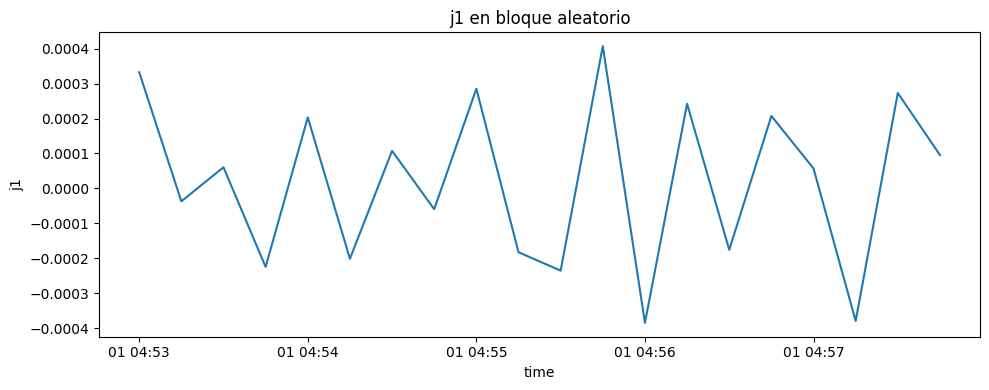

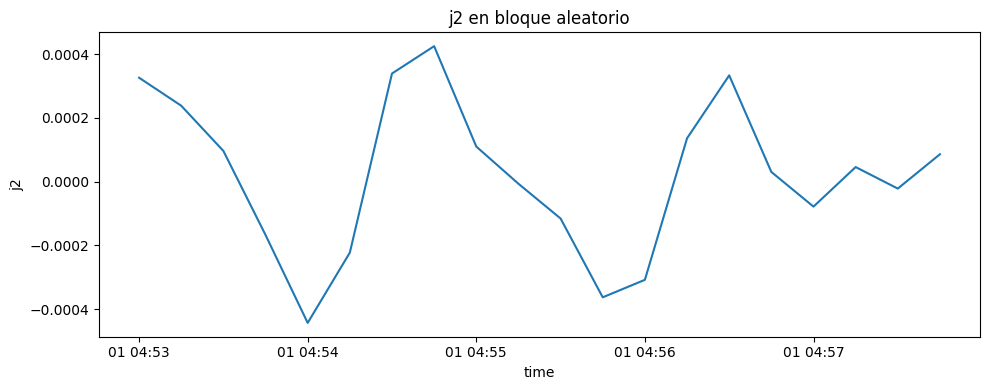

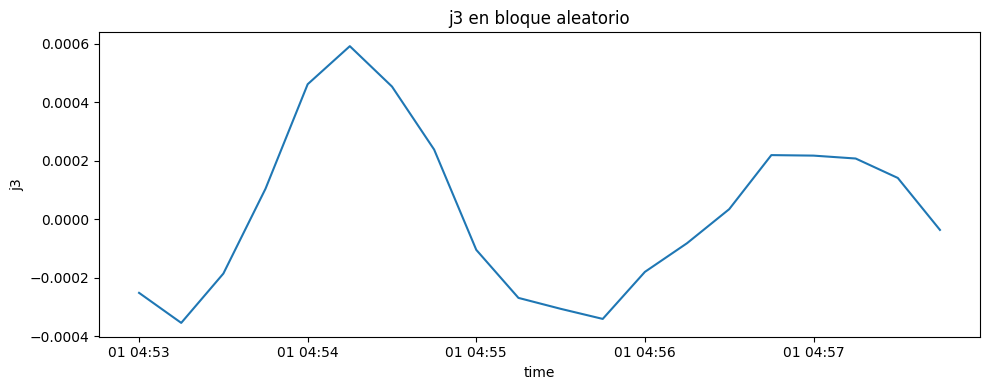

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-09-09 01:04:42
Fin   : 2024-09-09 01:09:42


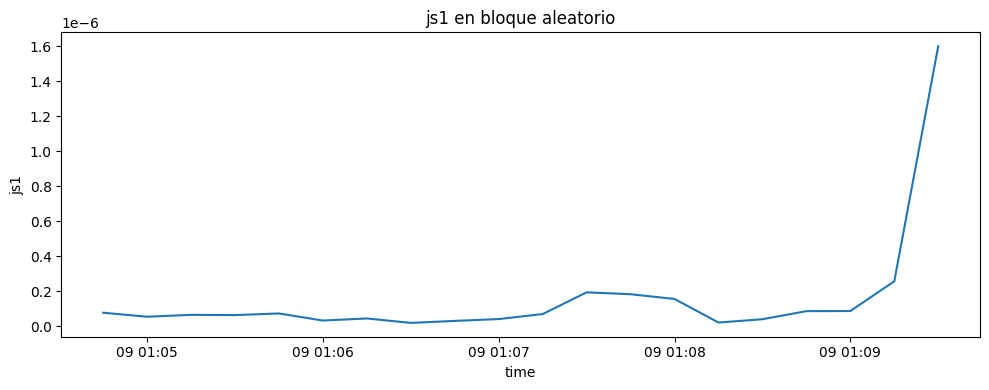

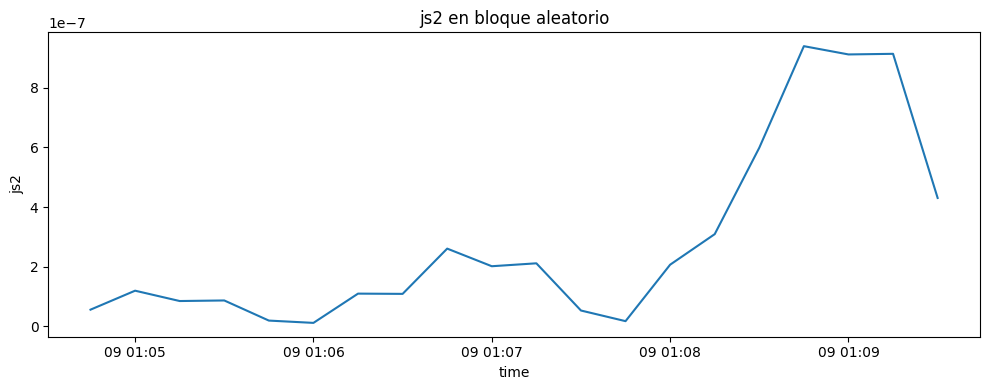

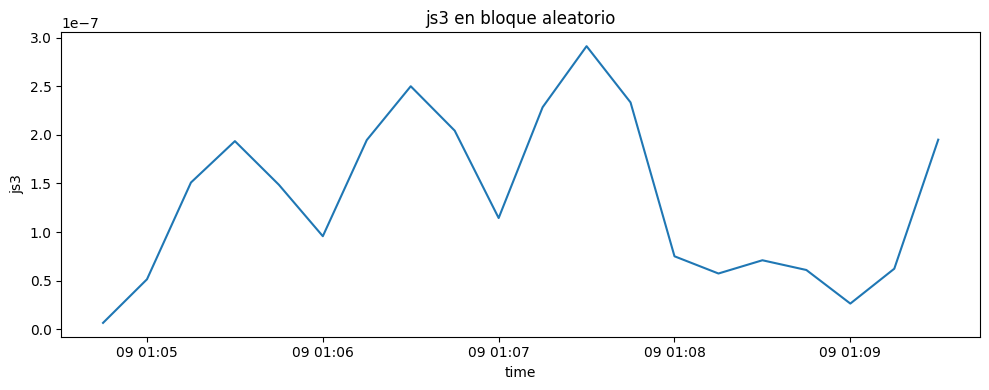

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


*Eshort, Emedium and ELong all RAW*

In [ ]:
df15["des"] = df15["j1"]
df15["dem"] = df15["j2"]
df15["del"] = df15["j3"]

In [ ]:
s = df15["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df15["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df15["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 204
des Nulls: 25
dem Ceros: 0
dem Nulls: 25
del Ceros: 0
del Nulls: 25


In [ ]:
df15["de_total"] = df15["des"] + df15["dem"] + df15["del"]

In [ ]:
df15["dvol_wlt"] = np.sqrt(df15["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df15["dlog_vol_wlt"] = np.log(df15["dvol_wlt"])

***Signature Plot***

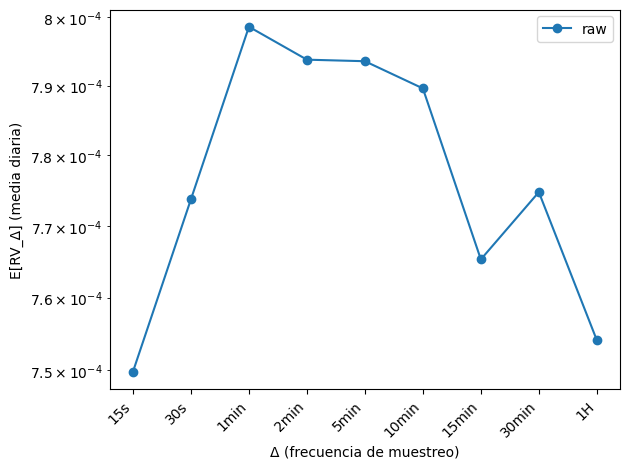

In [ ]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df15)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()


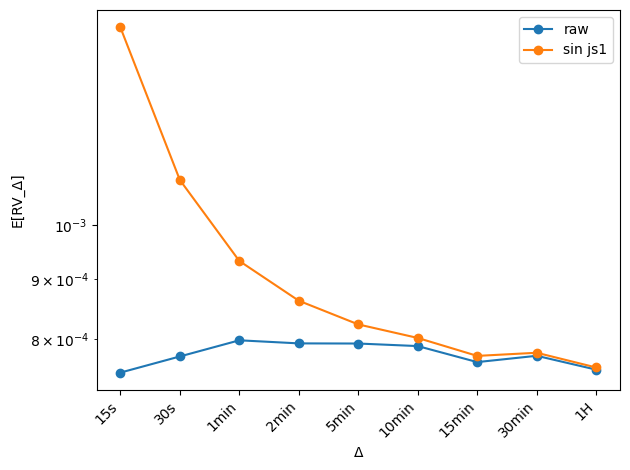

In [ ]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df15)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.028906349166752332), np.float64(-0.3383637881490195))

####SHAP

**HF**

R2 Score: 0.9207
MSE: 0.036014


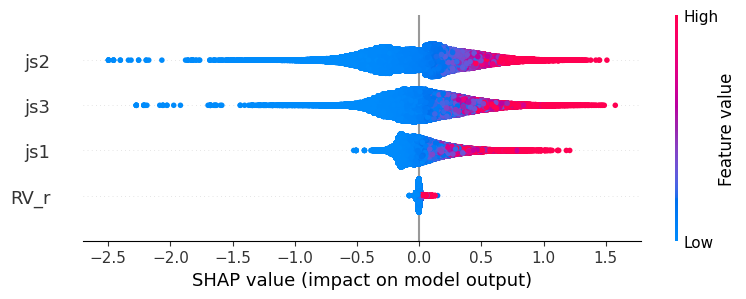

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].shift(-1) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**1 min**

R2 Score: 0.9222
MSE: 0.030751


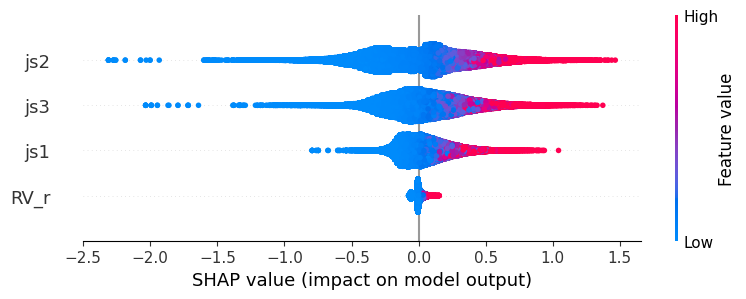

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=8).mean().shift(-4) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

R2 Score: 0.6238
MSE: 0.170948


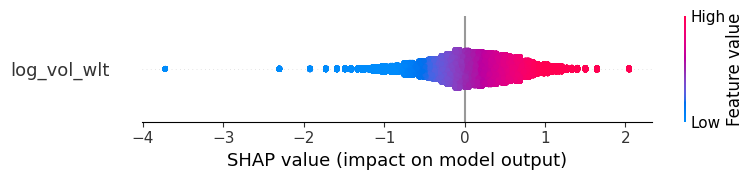

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

#NAVIE

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["log_vol_wlt"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].shift(-4) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**2 min**

R2 Score: 0.7499
MSE: 0.098796


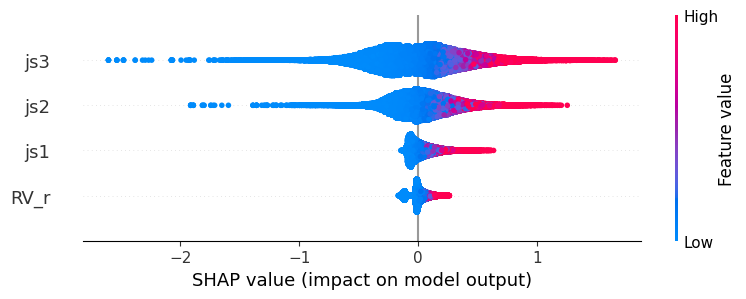

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=8).mean().shift(-8) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

**5 min**

R2 Score: 0.6649
MSE: 0.115202


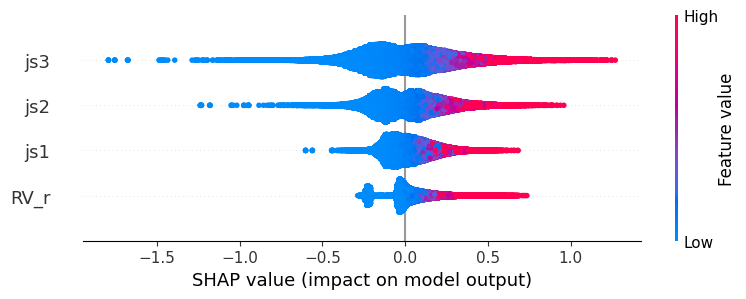

In [ ]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparación de Variables (Agregamos tus nuevas joyas: js1, js2, js3)
# Asumo que ya calculaste 'js1', 'js2', 'js3' (suavizados) y 'log_vol_wlt'
new_wavelet_features = ["js1", "js2", "js3", "RV_r"]
features = new_wavelet_features
target = "log_vol_wlt"

# --- CRUCIAL: Crear el LAG para predecir el FUTURO (t+1) ---
df = df15.copy()
df['target_future'] = df[target].rolling(window=20).mean().shift(-20) # Queremos predecir la intensidad del próximo período

# Limpieza estricta
df = df[features + ['target_future']].dropna()

X = df[features]
y = df['target_future']

# 2. Split Temporal (NADA de shuffle o stratify en series de tiempo)
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

# 3. Entrenamiento (Regressor, para ver la fuerza real de la señal)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=6, # Menos profundidad para evitar memorizar la persistencia
    learning_rate=0.05,
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 4. Evaluación de "Poder Predictivo"
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# 5. SHAP: Aquí veremos si js1, js2 y js3 son los jefes o son decorado
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualización
shap.summary_plot(shap_values, X_test)

In [ ]:
# TOP HORIZONTES
# 1 MINUTO
# 2 MINUTOS

#### SHAP REGIMENES

Preparación mínima (robusta)

In [ ]:
import numpy as np
import pandas as pd

s = df15["RV_r"].astype(float).clip(lower=1e-12)
lv = np.log(s)

Definir umbrales de ALTA y BAJA volatilidad

In [ ]:
q_low  = lv.quantile(0.25)
q_high = lv.quantile(0.75)

Estados persistentes (priorizar secuencias largas)

In [ ]:
state = pd.Series(
    np.where(lv >= q_high,  1,
    np.where(lv <= q_low,  -1, 0)),
    index=df15.index
)
#  1 = alta, -1 = baja, 0 = neutro

In [ ]:
MIN_LEN = 40   # ~10 minutos si df15 es 15s

grp = (state != state.shift()).cumsum()
segments = state.groupby(grp)

valid_segments = segments.filter(lambda x: len(x) >= MIN_LEN)

dfs

In [ ]:
df_high_vol = df15.loc[valid_segments[valid_segments == 1].index].copy()

In [ ]:
df_low_vol = df15.loc[valid_segments[valid_segments == -1].index].copy()

Violents transitions

In [ ]:
dlv = lv.diff()
jump_thr = dlv.abs().quantile(0.90)

In [ ]:
mask_bh = (
    (lv.shift(1) <= q_low) &
    (lv >= q_high) &
    (dlv >= jump_thr)
)

idx_bh = df15.index[mask_bh]

In [ ]:
W_PRE  = 80   # antes (~20 min)
W_POST = 80   # después

def extract_windows(idx, df, pre, post):
    out = []
    for i in idx:
        p = df.index.get_loc(i)
        a = max(0, p - pre)
        b = min(len(df), p + post)
        out.append(df.iloc[a:b])
    return pd.concat(out).sort_index().drop_duplicates()

df_baja_alta = extract_windows(idx_bh, df15, W_PRE, W_POST)

In [ ]:
mask_hb = (
    (lv.shift(1) >= q_high) &
    (lv <= q_low) &
    (dlv <= -jump_thr)
)

idx_hb = df15.index[mask_hb]

df_alta_baja = extract_windows(idx_hb, df15, W_PRE, W_POST)


**SHAP**

**MODELO ANTERIOR**

HIGH VOLATILITY

In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_hv = df_high_vol.copy()
df_hv["target_future"] = df_hv["log_vol_wlt"].shift(-4)

df_hv = df_hv[expected + ["target_future"]].dropna()

X_hv = df_hv[expected]
y_hv = df_hv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.2715
MSE: 0.395580


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_lv = df_low_vol.copy()
df_lv["target_future"] = df_lv["log_vol_wlt"].shift(-4)

df_lv = df_lv[expected + ["target_future"]].dropna()

X_hv = df_lv[expected]
y_hv = df_lv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.5331
MSE: 2.253817


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_lhv = df_baja_alta.copy()
df_lhv["target_future"] = df_lhv["log_vol_wlt"].shift(-4)

df_lhv = df_lhv[expected + ["target_future"]].dropna()

X_hv = df_lhv[expected]
y_hv = df_lhv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH-LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH-LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.6678
MSE: 0.191213


In [ ]:
model.get_booster().feature_names
expected = model.get_booster().feature_names

df_hlv = df_alta_baja.copy()
df_hlv["target_future"] = df_hlv["log_vol_wlt"].shift(-4)

df_hlv = df_hlv[expected + ["target_future"]].dropna()

X_hv = df_hlv[expected]
y_hv = df_hlv["target_future"]

y_pred_hv = model.predict(X_hv)

from sklearn.metrics import r2_score, mean_squared_error
print("HIGH-LOW VOL REGIME")
print("Features usadas:", expected)
print(f"R2:  {r2_score(y_hv, y_pred_hv):.4f}")
print(f"MSE: {mean_squared_error(y_hv, y_pred_hv):.6f}")

HIGH-LOW VOL REGIME
Features usadas: ['js1', 'js2', 'js3', 'RV_r']
R2:  0.6623
MSE: 0.190564


**MODELOS AJUSTADOS**

In [ ]:
features = ["js1","js2","js3","RV_r"]
target = "log_vol_wlt"

df = df_hv.copy()
df["target_future"] = df[target].shift(-4)
df = df[features + ["target_future"]].dropna()

X, y = df[features], df["target_future"]

# split temporal
n = len(df); tr = int(n*0.7); va = int(n*0.2)
X_train, y_train = X.iloc[:tr], y.iloc[:tr]
X_val, y_val     = X.iloc[tr:tr+va], y.iloc[tr:tr+va]
X_test, y_test   = X.iloc[tr+va:], y.iloc[tr+va:]

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500, max_depth=6, learning_rate=0.05,
    tree_method="hist", early_stopping_rounds=50
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

In [ ]:
import shap
from sklearn.metrics import r2_score, mean_squared_error

# Predicciones test
y_pred = model.predict(X_test)

# Métricas
print(f"R2:  {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

# SHAP beeswarm
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bee")

####Blocks minutes

15 minutes

In [ ]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-3233109994.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-3233109994.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.43058979105791767
Spearman: 0.7876467959899837
Kendall : 0.5951426588259752


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.7876467959899837
Kendall : 0.5951426588259752


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


5 minutes

In [ ]:
import numpy as np
import pandas as pd

df15["time"] = pd.to_datetime(df15["time"])
df_ = df15.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-304541807.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-304541807.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4536667369576258
Spearman: 0.7817484109407691
Kendall : 0.5892922856151096


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.7817484109407691
Kendall : 0.5892922856151096


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


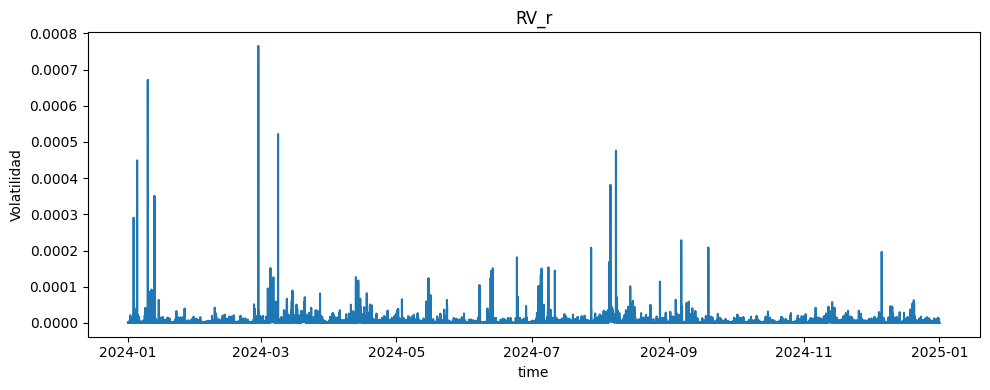

In [ ]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

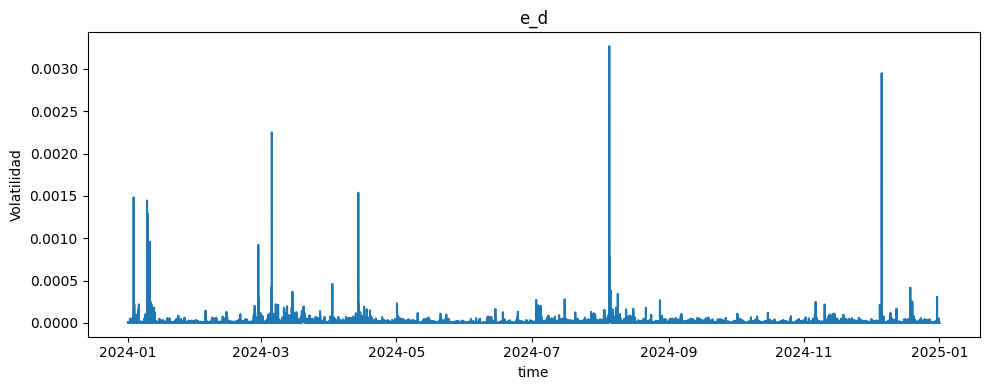

In [ ]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

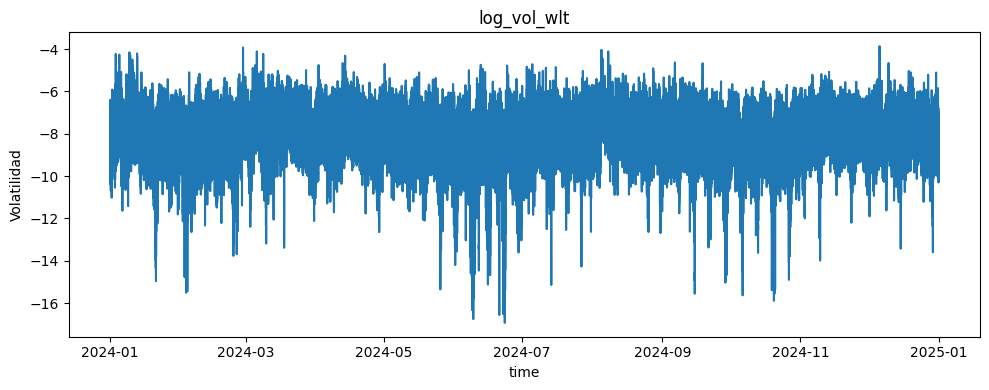

In [ ]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [ ]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(0.009346382080625977), np.float64(0.0037274259736032457))

In [ ]:
#no hay leakage

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   54999.562312        0.0
 10  73851.169901        0.0
 20  92422.459761        0.0,
 'js2':          lb_stat  lb_pvalue
 5   49174.384471        0.0
 10  62040.193222        0.0
 20  74858.937948        0.0,
 'js3':          lb_stat  lb_pvalue
 5   35530.265008        0.0
 10  44092.392903        0.0
 20  51618.090716        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [ ]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.4119542112895267),
 'js2': np.float64(0.4066213093031348),
 'js3': np.float64(0.4400764387086965)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [ ]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.2973378807779419)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

# CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# Guardar en formato Parquet, conservando la estructura y tipos
mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

KeyboardInterrupt: 

In [ ]:
mf1.info()